# <font color=#0099CC>**Batch Runner — All Models (Robust)**</font>

Auto-discovers checkpoints, auto-detects architecture from `.h5` weight shapes,
runs the full pipeline for each model. If any model fails, it logs the error
and continues to the next.

**Run on Colab** (requires TensorFlow for inference).

---
## <font color=#0099CC>**1. ENVIRONMENT**</font>

In [9]:
import os, sys, json, shutil, importlib, warnings, time, traceback
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
warnings.filterwarnings('ignore', category=FutureWarning)

def detect_env():
    try:
        import google.colab
        return 'colab'
    except ImportError:
        return 'local'

ENV = detect_env()
if ENV == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/Taller4_DL_MIAX'
else:
    BASE = os.path.abspath(os.path.join(os.getcwd(), '..'))

SRC = os.path.join(BASE, '01_src_compartido')
PORTFOLIO_DIR = os.path.join(BASE, '11_Portfolio')
for p in [SRC, PORTFOLIO_DIR]:
    if p not in sys.path:
        sys.path.insert(0, p)

cache = os.path.join(PORTFOLIO_DIR, '__pycache__')
if os.path.isdir(cache): shutil.rmtree(cache)

print(f'> Entorno: {ENV}\n> BASE: {BASE}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
> Entorno: colab
> BASE: /content/drive/MyDrive/Taller4_DL_MIAX


---
## <font color=#0099CC>**2. PARAMETERS & DISCOVER CHECKPOINTS**</font>

In [10]:
# ╔══════════════════════════════════════════════════════════╗
# ║  GLOBAL PARAMETERS (apply to all models)                 ║
# ╚══════════════════════════════════════════════════════════╝
V_OUT           = 90
TOP_K           = 5
CASH_RATE       = 0.0
DATA_START_YEAR = '2025-01-01'
OFFSETS         = [0, 5, 10, 15, 20]

import model_builder
importlib.reload(model_builder)
from model_builder import discover_checkpoints, build_and_load_from_h5

checkpoints = discover_checkpoints(BASE, v_out_filter=V_OUT)

print(f'-- Discovered {len(checkpoints)} checkpoint(s) with v_out={V_OUT} --')
for i, ck in enumerate(checkpoints):
    print(f'  [{i}] {ck["run_tag"]:35s}  v_in={ck["v_in"]:2d}  file={ck["filename"]}')

if not checkpoints:
    raise RuntimeError('No checkpoints found!')

-- Discovered 12 checkpoint(s) with v_out=90 --
  [0] inv_cnn_vin10_vout90                 v_in=10  file=inv_cnn_vin10_vout90_best.weights.h5
  [1] inv_cnn_vin30_vout90                 v_in=30  file=inv_cnn_vin30_vout90_best.weights.h5
  [2] inv_cnn_vin5_vout90                  v_in= 5  file=inv_cnn_vin5_vout90_best.weights.h5
  [3] inv_cnn_vin90_vout90                 v_in=90  file=inv_cnn_vin90_vout90_best.weights.h5
  [4] inv_mixto_vin30_vout90               v_in=30  file=inv_mixto_vin30_vout90_best.weights.h5
  [5] inv_mixto_vin5_vout90                v_in= 5  file=inv_mixto_vin5_vout90_best.weights.h5
  [6] inv_mixto_vin90_vout90               v_in=90  file=inv_mixto_vin90_vout90_best.weights.h5
  [7] inv_mlp_vin10_vout90                 v_in=10  file=inv_mlp_vin10_vout90_best.weights.h5
  [8] inv_mlp_vin5_vout90                  v_in= 5  file=inv_mlp_vin5_vout90_best.weights.h5
  [9] inv_mlp_vin90_vout90                 v_in=90  file=inv_mlp_vin90_vout90_best.weights.h5
  [10] in

---
## <font color=#0099CC>**3. SHARED DATA (load once)**</font>

In [11]:
import tensorflow as tf
print(f'> TF {tf.__version__}, GPU: {tf.config.list_physical_devices("GPU")}')

from dataset_utils import (
    TICKERS, D_FRAC_INV, RANDOM_STATE_VAL,
    load_data, create_dataset, get_partitions_temporal,
)
from metrics_utils import calc_mae_all
import metrics_utils
metrics_utils.BASE_DRIVE = BASE

TICKERS = list(TICKERS)
N_ASSETS = len(TICKERS)

# Load frac-diff data (shared)
data_fd, df_hist = load_data(d_frac=D_FRAC_INV, verbose=True)
fd_full = pd.DataFrame(data_fd, index=df_hist.index[-len(data_fd):], columns=TICKERS)

# Download prices (shared)
import data_loader
importlib.reload(data_loader)
from data_loader import download_prices, get_trading_dates, compute_rebalancing_dates, prepare_log_prices
from frac_diff_utils import ffd_weights, ffd_invert_expected_return

dl_start = str(pd.Timestamp(DATA_START_YEAR) - pd.DateOffset(years=10))
dl_end   = str(pd.Timestamp('today') + pd.DateOffset(days=1))
prices_df = download_prices(TICKERS, start=dl_start, end=dl_end, verbose=True)
log_prices = prepare_log_prices(prices_df)

all_trading = get_trading_dates(prices_df, DATA_START_YEAR, str(prices_df.index[-1].date()))
daily_returns = prices_df.pct_change().loc[all_trading]
weights_ffd = ffd_weights(D_FRAC_INV, 1e-5)

print(f'\n> Trading days: {len(all_trading)} ({all_trading[0].date()} -> {all_trading[-1].date()})')

> TF 2.20.0, GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
> Descargando datos desde 1945-01-01 hasta hoy...


[*********************100%***********************]  23 of 23 completed


> Frac-diff aplicada — d=0.4, L=1458 pesos, 1457 filas iniciales descartadas (~8.99% del histórico).
> Shape resultante: (14747, 23)
> yfinance version : 0.2.66
> Downloading 23 tickers individually (2015-01-01 -> 2026-05-22) ...
  [ 1/23]   AEP  2,862 days  [2015-01-02 -> 2026-05-20]
  [ 2/23]    BA  2,862 days  [2015-01-02 -> 2026-05-20]
  [ 3/23]   CAT  2,862 days  [2015-01-02 -> 2026-05-20]
  [ 4/23]   CNP  2,862 days  [2015-01-02 -> 2026-05-20]
  [ 5/23]   CVX  2,862 days  [2015-01-02 -> 2026-05-20]
  [ 6/23]   DIS  2,862 days  [2015-01-02 -> 2026-05-20]
  [ 7/23]   DTE  2,862 days  [2015-01-02 -> 2026-05-20]
  [ 8/23]    ED  2,862 days  [2015-01-02 -> 2026-05-20]
  [ 9/23]    GD  2,862 days  [2015-01-02 -> 2026-05-20]
  [10/23]    GE  2,862 days  [2015-01-02 -> 2026-05-20]
  [11/23]   HON  2,862 days  [2015-01-02 -> 2026-05-20]
  [12/23]   HPQ  2,862 days  [2015-01-02 -> 2026-05-20]
  [13/23]   IBM  2,862 days  [2015-01-02 -> 2026-05-20]
  [14/23]    IP  2,862 days  [2015-01-02 -

---
## <font color=#0099CC>**4. BACKTEST ENGINE**</font>

In [12]:
from scipy.stats import spearmanr

def run_inference_at_date(rebal_date, model_obj, scaler_obj, v_in):
    fd_up_to = fd_full.loc[:rebal_date]
    if len(fd_up_to) < v_in:
        return None, None
    window = scaler_obj.transform(fd_up_to.iloc[-v_in:].values)
    pred = model_obj.predict(window[np.newaxis, ...], verbose=0).squeeze()
    lp = log_prices.loc[:rebal_date].values
    exp_ret = ffd_invert_expected_return(pred, lp, weights_ffd, V_OUT)
    return pred, exp_ret


def select_top_k(exp_ret, tickers, top_k):
    pairs = sorted(zip(tickers, exp_ret), key=lambda x: x[1], reverse=True)
    return [(t, er) for t, er in pairs[:top_k] if er > 0]


def run_single_backtest(offset, model_obj, scaler_obj, v_in):
    daily_rf = (1 + CASH_RATE) ** (1/252) - 1
    bt = all_trading[offset:]
    rdates = compute_rebalancing_dates(bt, V_OUT)
    last_ri = list(bt).index(rdates[-1])
    end_i = min(last_ri + V_OUT, len(bt) - 1)
    bt = bt[:end_i + 1]

    alerts = []
    lwd = end_i - last_ri
    if lwd < V_OUT:
        alerts.append(f'Last window: {lwd}/{V_OUT} days (data ends {bt[-1].date()})')

    nav_a=[1.]; nav_b=[1.]; nav_c=[1.]; nav_bm2=[1.]
    ha={}; ca=1.; hb={}; cb=1.; crb={}; clb=set()
    hc={}; cc=1.; bw=pd.Series(1./N_ASSETS, index=TICKERS)
    cw=-1; wlog=[]

    for di, date in enumerate(bt):
        wi=0
        for ii in range(len(rdates)-1,-1,-1):
            if date>=rdates[ii]: wi=ii; break
        if wi!=cw:
            cw=wi; rd=rdates[wi]
            _, er=run_inference_at_date(rd, model_obj, scaler_obj, v_in)
            sel=select_top_k(er, TICKERS, TOP_K) if er is not None else []
            weq=1./TOP_K if sel else 0
            ha={t:weq for t,_ in sel}; ca=1.-weq*len(sel)
            hb={t:(weq,e) for t,e in sel}; cb=ca; crb={t:0. for t,_ in sel}; clb=set()
            if sel:
                tot=sum(e for _,e in sel)
                if tot>0: hc={t:e/tot for t,e in sel}; cc=0.
                else: hc={}; cc=1.
            else: hc={}; cc=1.
            bw=pd.Series(1./N_ASSETS, index=TICKERS)
            epa=sum(weq*e for _,e in sel) if sel else 0
            epc=sum(hc.get(t,0)*e for t,e in sel) if sel else 0
            wlog.append({'window':wi,'rebal_date':rd.strftime('%Y-%m-%d'),
                'selected':[t for t,_ in sel],'exp_returns':[e for _,e in sel],
                'weights_c':{t:hc.get(t,0) for t,_ in sel},
                'n_selected':len(sel),'exp_port_ret_a':epa,'exp_port_ret_c':epc})
        if di==0: continue
        dr=daily_returns.loc[date]
        ra=sum(ha.get(t,0)*dr[t] for t in TICKERS)+ca*daily_rf; nav_a.append(nav_a[-1]*(1+ra))
        rb=0.
        for t in list(hb):
            if t in clb: continue
            w,thr=hb[t]; crb[t]=(1+crb[t])*(1+dr[t])-1; rb+=w*dr[t]
            if crb[t]>=thr: clb.add(t); cb+=w
        rb+=cb*daily_rf; nav_b.append(nav_b[-1]*(1+rb))
        rc=sum(hc.get(t,0)*dr[t] for t in TICKERS)+cc*daily_rf; nav_c.append(nav_c[-1]*(1+rc))
        rbm=(bw*dr).sum(); nav_bm2.append(nav_bm2[-1]*(1+rbm))
        bw=bw*(1+dr); bw=bw/bw.sum()

    ew=1./N_ASSETS
    np_=prices_df.loc[bt]/prices_df.loc[bt[0]]
    bm1s=(np_*ew).sum(axis=1)
    nd=bt[:len(nav_a)]

    for wl in wlog:
        rd=pd.Timestamp(wl['rebal_date'])
        ri=list(bt).index(rd); ei=min(ri+V_OUT,len(bt)-1); ed=bt[ei]
        wl['end_date']=ed.strftime('%Y-%m-%d'); wl['actual_days']=ei-ri
        if wl['actual_days']<V_OUT:
            alerts.append(f'Window {wl["window"]}: {wl["actual_days"]}/{V_OUT} days')
        ar={t:(prices_df.loc[ed,t]/prices_df.loc[rd,t])-1 for t in wl['selected']}
        wl['actual_returns']=ar
        weq=1./TOP_K if wl['selected'] else 0
        wl['actual_port_ret_a']=sum(weq*ar[t] for t in wl['selected']) if wl['selected'] else 0
        wl['actual_port_ret_c']=sum(wl['weights_c'][t]*ar[t] for t in wl['selected']) if wl['selected'] else 0
        _, ef=run_inference_at_date(rd, model_obj, scaler_obj, v_in)
        if ef is not None:
            af=[(prices_df.loc[ed,t]/prices_df.loc[rd,t])-1 for t in TICKERS]
            c,p=spearmanr(ef,af); wl['spearman_rho']=c; wl['spearman_p']=p
            wl['direction_pct']=sum(1 for e,a in zip(ef,af) if np.sign(e)==np.sign(a))/N_ASSETS
        else: wl['spearman_rho']=None; wl['spearman_p']=None; wl['direction_pct']=None

    return {'offset':offset,'start':bt[0].strftime('%Y-%m-%d'),'end':bt[-1].strftime('%Y-%m-%d'),
        'n_days':len(bt),'alerts':alerts,
        'nav':{'A':pd.Series(nav_a,index=nd),'B':pd.Series(nav_b,index=nd),
               'C':pd.Series(nav_c,index=nd),'BM1':bm1s.loc[nd],'BM2':pd.Series(nav_bm2,index=nd)},
        'window_log':wlog,
        'final_ret':{'A':nav_a[-1]-1,'B':nav_b[-1]-1,'C':nav_c[-1]-1,
                     'BM1':float(bm1s.iloc[-1])-1,'BM2':nav_bm2[-1]-1}}

print('Engine ready.')

Engine ready.


---
## <font color=#0099CC>**5. RUN ALL MODELS**</font>

Each model is wrapped in try/except. Failures are logged and skipped.


######################################################################
  MODEL [1/12]: inv_cnn_vin10_vout90
  v_in=10  v_out=90  file=inv_cnn_vin10_vout90_best.weights.h5
######################################################################
  Scaler: X_tr (11518, 10, 23)


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


> Auto-built cnn: 39,703 params from inv_cnn_vin10_vout90_best.weights.h5
  MAE tr=0.01865  val=0.02156  test=0.02600
  ⚠ Offset 0: Last window: 75/90 days (data ends 2026-05-20)
  ⚠ Offset 0: Window 3: 75/90 days
  ⚠ Offset 5: Last window: 70/90 days (data ends 2026-05-20)
  ⚠ Offset 5: Window 3: 70/90 days
  ⚠ Offset 10: Last window: 65/90 days (data ends 2026-05-20)
  ⚠ Offset 10: Window 3: 65/90 days
  ⚠ Offset 15: Last window: 60/90 days (data ends 2026-05-20)
  ⚠ Offset 15: Window 3: 60/90 days
  ⚠ Offset 20: Last window: 55/90 days (data ends 2026-05-20)
  ⚠ Offset 20: Window 3: 55/90 days
  AVG: A=+16.40%  B=+13.03%  C=+35.01%  BM1=+24.84%  BM2=+23.54%


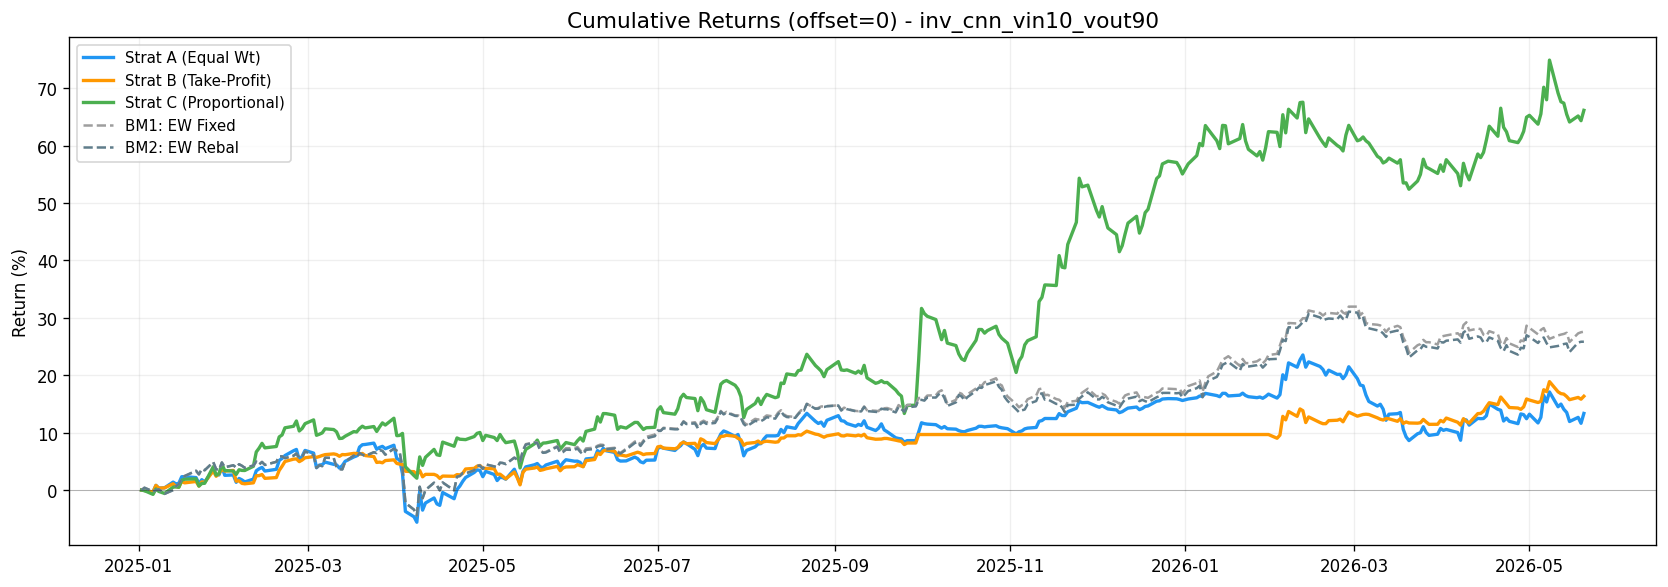

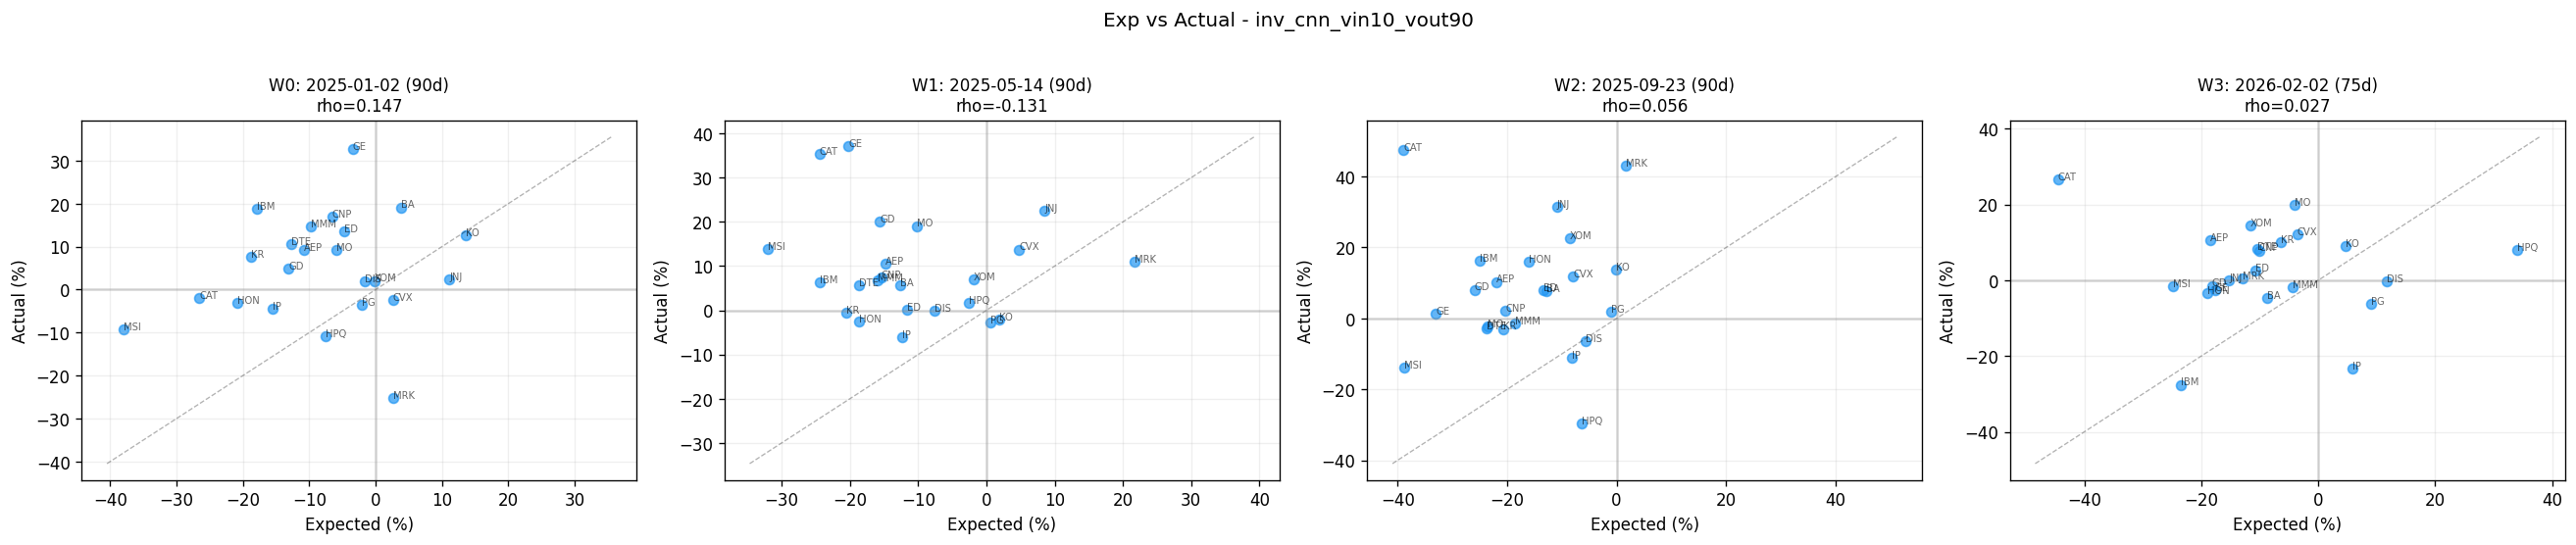

  ✓ Saved to inv_cnn_vin10_vout90/ (22s)

######################################################################
  MODEL [2/12]: inv_cnn_vin30_vout90
  v_in=30  v_out=90  file=inv_cnn_vin30_vout90_best.weights.h5
######################################################################
  Scaler: X_tr (11462, 30, 23)


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


> Auto-built cnn: 37,575 params from inv_cnn_vin30_vout90_best.weights.h5
  MAE tr=0.02158  val=0.02843  test=0.03846
  ⚠ Offset 0: Last window: 75/90 days (data ends 2026-05-20)
  ⚠ Offset 0: Window 3: 75/90 days
  ⚠ Offset 5: Last window: 70/90 days (data ends 2026-05-20)
  ⚠ Offset 5: Window 3: 70/90 days
  ⚠ Offset 10: Last window: 65/90 days (data ends 2026-05-20)
  ⚠ Offset 10: Window 3: 65/90 days
  ⚠ Offset 15: Last window: 60/90 days (data ends 2026-05-20)
  ⚠ Offset 15: Window 3: 60/90 days
  ⚠ Offset 20: Last window: 55/90 days (data ends 2026-05-20)
  ⚠ Offset 20: Window 3: 55/90 days
  AVG: A=+4.14%  B=+3.92%  C=+18.96%  BM1=+24.84%  BM2=+23.54%


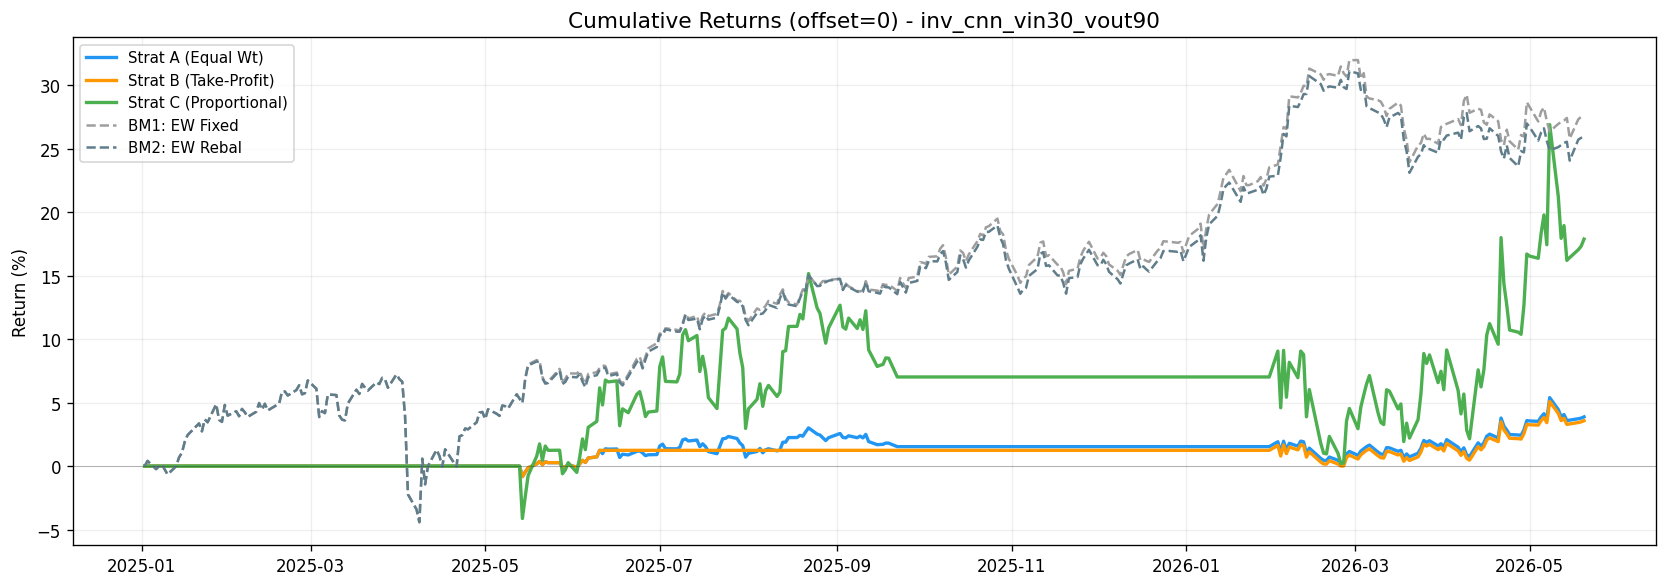

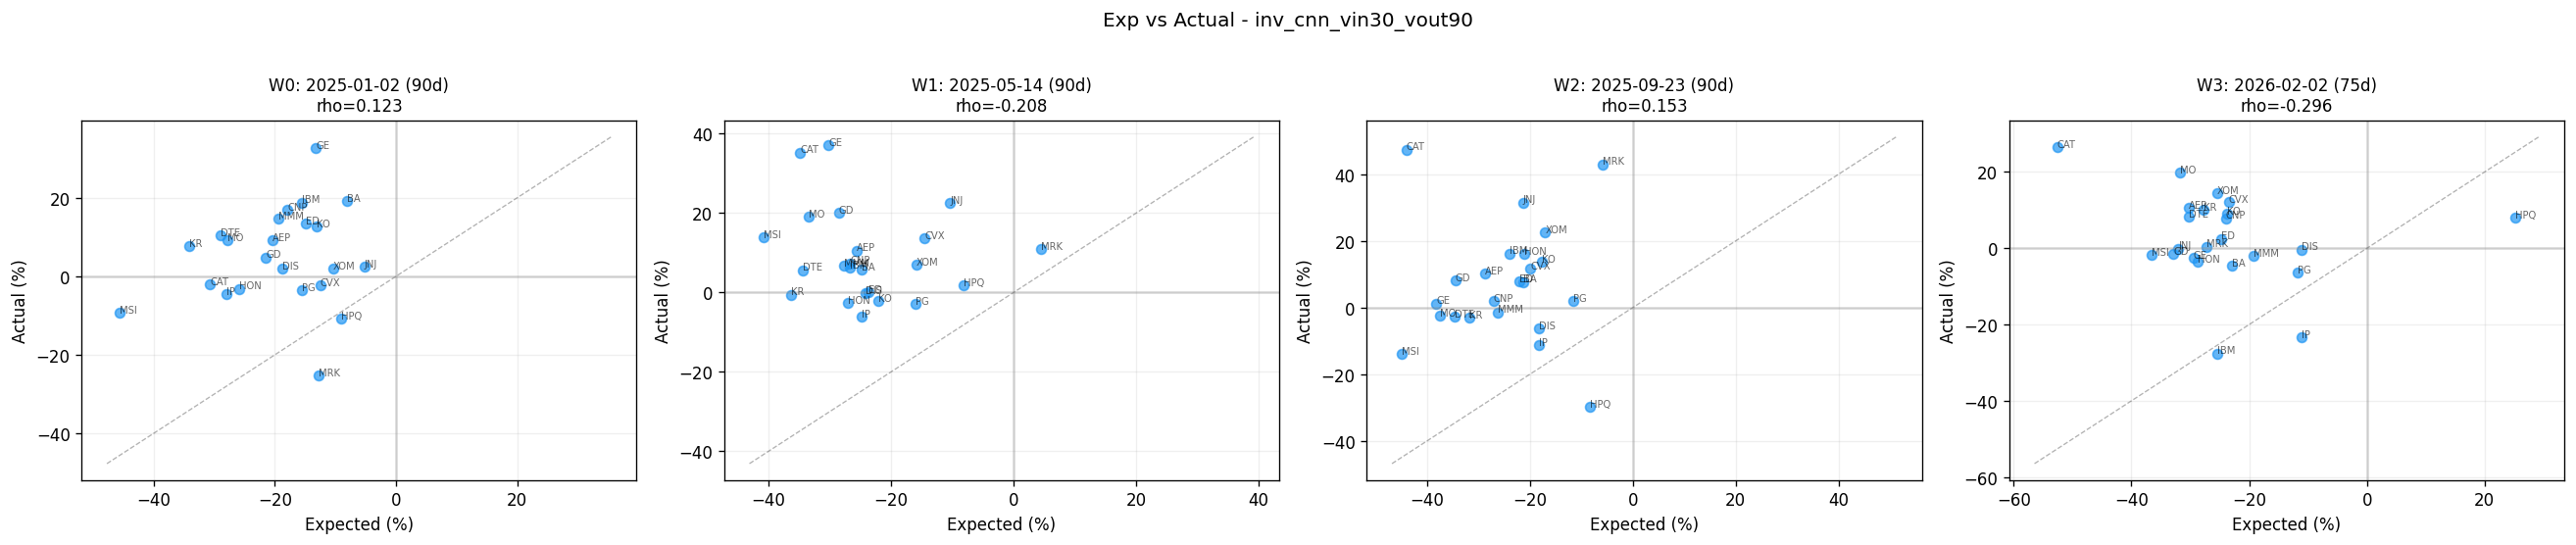

  ✓ Saved to inv_cnn_vin30_vout90/ (24s)

######################################################################
  MODEL [3/12]: inv_cnn_vin5_vout90
  v_in=5  v_out=90  file=inv_cnn_vin5_vout90_best.weights.h5
######################################################################
  Scaler: X_tr (11533, 5, 23)


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


> Auto-built cnn: 14,567 params from inv_cnn_vin5_vout90_best.weights.h5
  MAE tr=0.01876  val=0.02098  test=0.03128
  ⚠ Offset 0: Last window: 75/90 days (data ends 2026-05-20)
  ⚠ Offset 0: Window 3: 75/90 days
  ⚠ Offset 5: Last window: 70/90 days (data ends 2026-05-20)
  ⚠ Offset 5: Window 3: 70/90 days
  ⚠ Offset 10: Last window: 65/90 days (data ends 2026-05-20)
  ⚠ Offset 10: Window 3: 65/90 days
  ⚠ Offset 15: Last window: 60/90 days (data ends 2026-05-20)
  ⚠ Offset 15: Window 3: 60/90 days
  ⚠ Offset 20: Last window: 55/90 days (data ends 2026-05-20)
  ⚠ Offset 20: Window 3: 55/90 days
  AVG: A=+14.36%  B=+7.27%  C=+50.84%  BM1=+24.84%  BM2=+23.54%


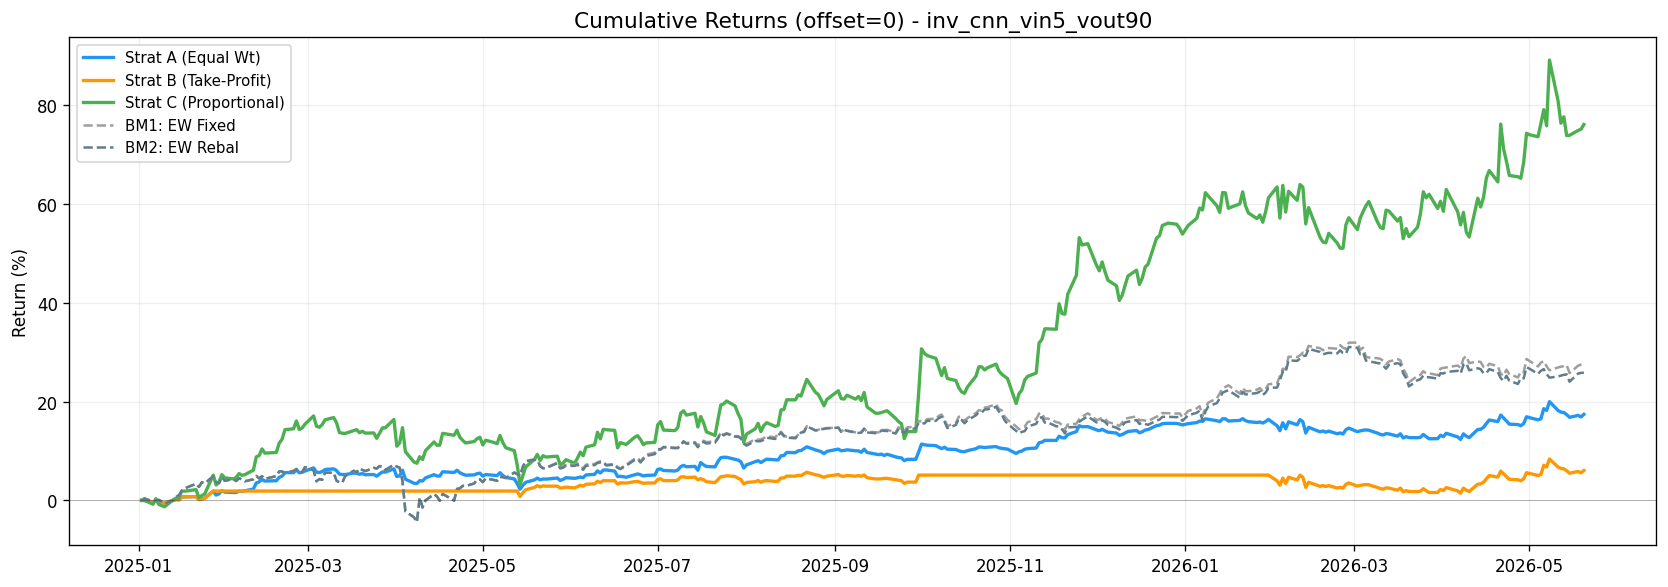

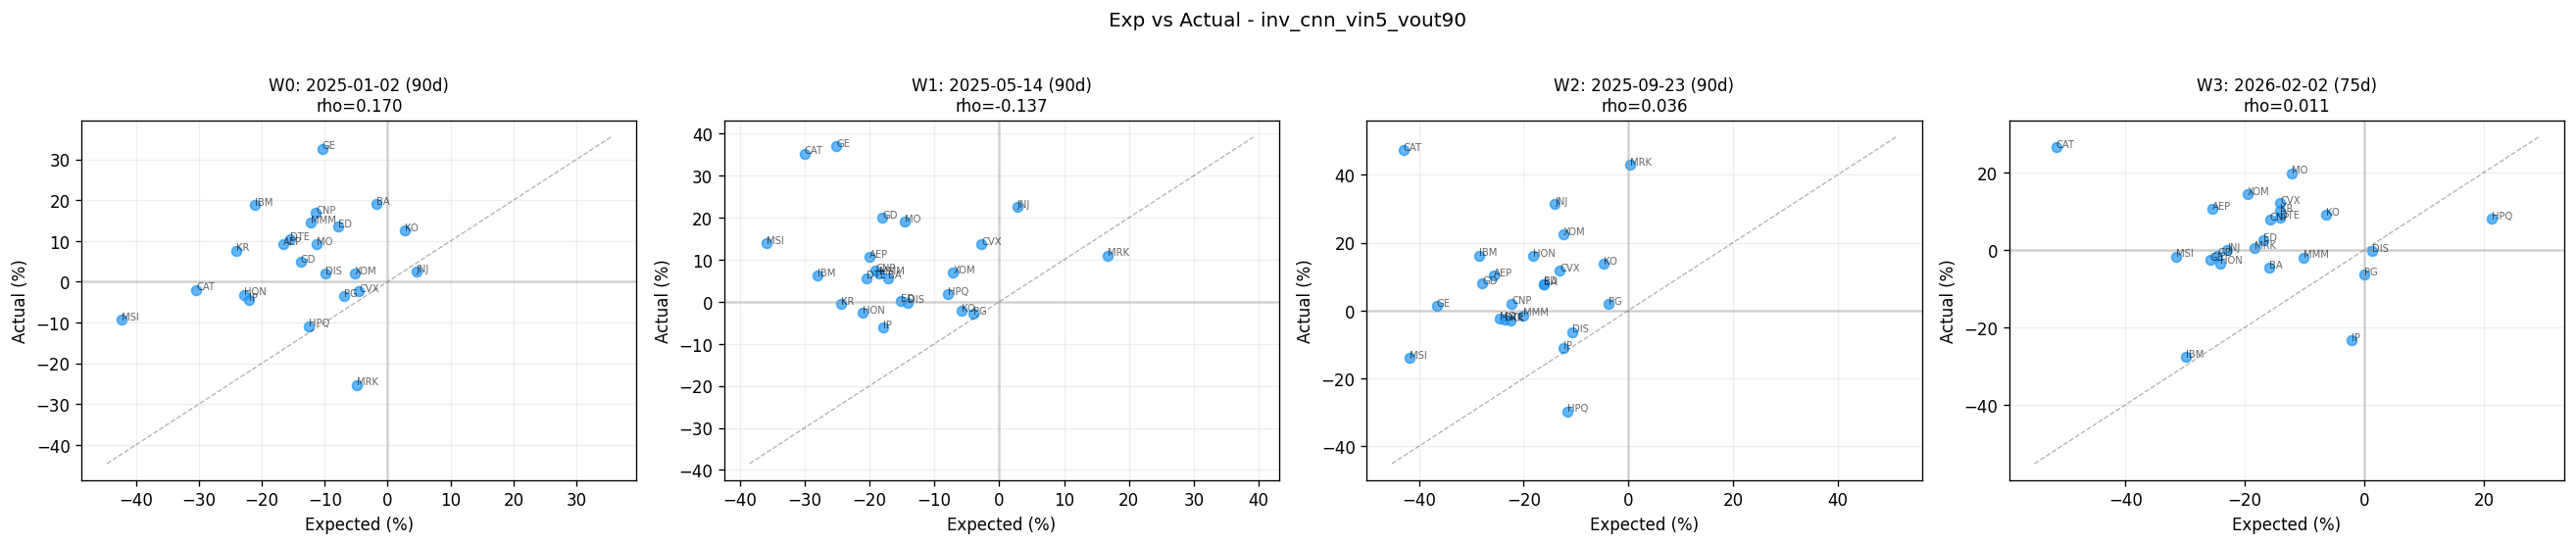

  ✓ Saved to inv_cnn_vin5_vout90/ (23s)

######################################################################
  MODEL [4/12]: inv_cnn_vin90_vout90
  v_in=90  v_out=90  file=inv_cnn_vin90_vout90_best.weights.h5
######################################################################
  Scaler: X_tr (11294, 90, 23)


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


> Auto-built cnn: 39,703 params from inv_cnn_vin90_vout90_best.weights.h5
  MAE tr=0.02284  val=0.02292  test=0.03189
  ⚠ Offset 0: Last window: 75/90 days (data ends 2026-05-20)
  ⚠ Offset 0: Window 3: 75/90 days
  ⚠ Offset 5: Last window: 70/90 days (data ends 2026-05-20)
  ⚠ Offset 5: Window 3: 70/90 days
  ⚠ Offset 10: Last window: 65/90 days (data ends 2026-05-20)
  ⚠ Offset 10: Window 3: 65/90 days
  ⚠ Offset 15: Last window: 60/90 days (data ends 2026-05-20)
  ⚠ Offset 15: Window 3: 60/90 days
  ⚠ Offset 20: Last window: 55/90 days (data ends 2026-05-20)
  ⚠ Offset 20: Window 3: 55/90 days
  AVG: A=+7.67%  B=+5.53%  C=+30.30%  BM1=+24.84%  BM2=+23.54%


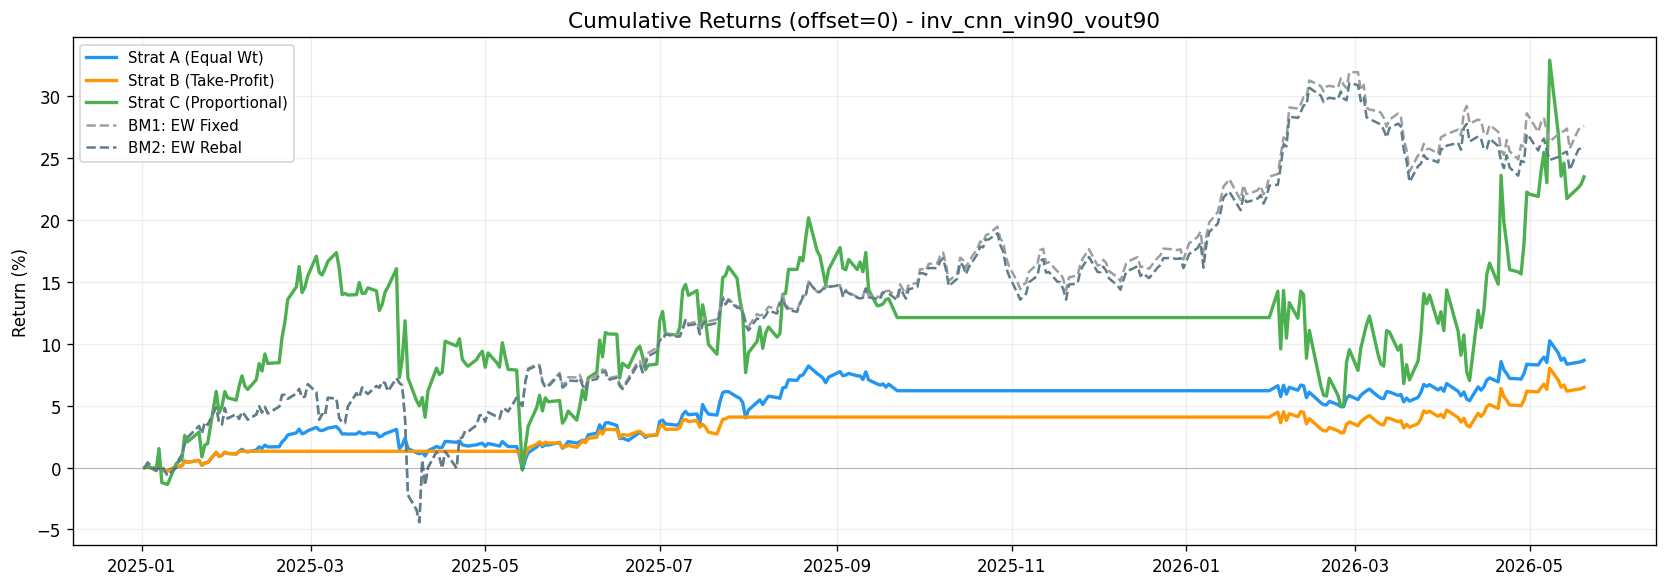

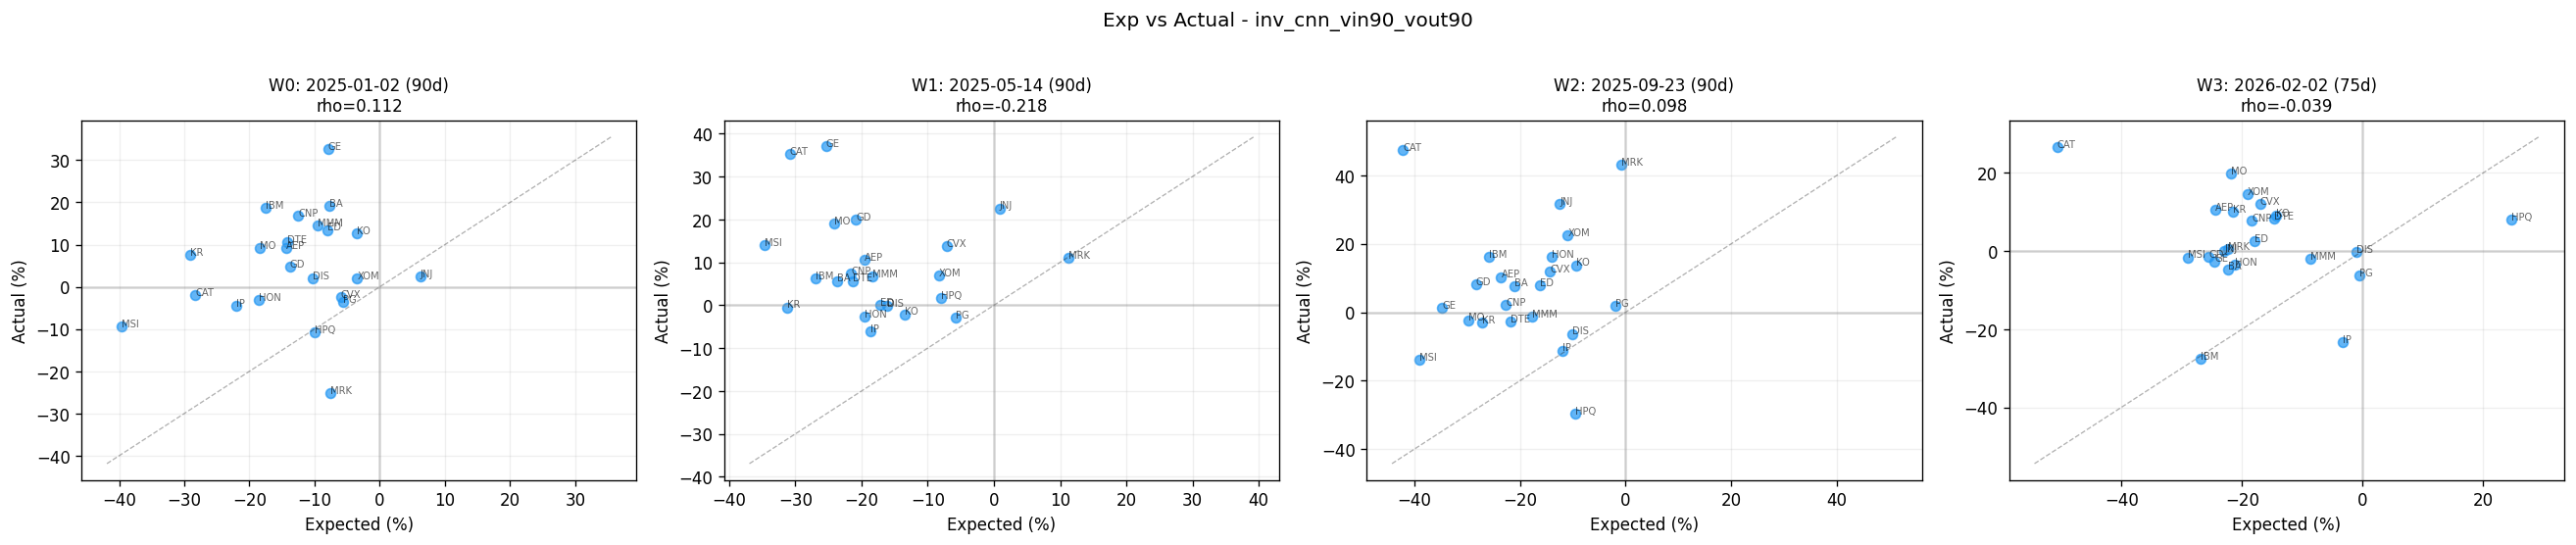

  ✓ Saved to inv_cnn_vin90_vout90/ (25s)

######################################################################
  MODEL [5/12]: inv_mixto_vin30_vout90
  v_in=30  v_out=90  file=inv_mixto_vin30_vout90_best.weights.h5
######################################################################
  Scaler: X_tr (11462, 30, 23)


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 27 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


> Auto-built mlp: 0 params from inv_mixto_vin30_vout90_best.weights.h5
  ✗ FAILED: ValueError: operands could not be broadcast together with shapes (11462,690) (11462,23) 
  Skipping to next model...


######################################################################
  MODEL [6/12]: inv_mixto_vin5_vout90
  v_in=5  v_out=90  file=inv_mixto_vin5_vout90_best.weights.h5
######################################################################
  Scaler: X_tr (11533, 5, 23)


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 28 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


> Auto-built mixto: 60,055 params from inv_mixto_vin5_vout90_best.weights.h5
  MAE tr=0.03539  val=0.05367  test=0.06884
  ⚠ Offset 0: Last window: 75/90 days (data ends 2026-05-20)
  ⚠ Offset 0: Window 3: 75/90 days
  ⚠ Offset 5: Last window: 70/90 days (data ends 2026-05-20)
  ⚠ Offset 5: Window 3: 70/90 days
  ⚠ Offset 10: Last window: 65/90 days (data ends 2026-05-20)
  ⚠ Offset 10: Window 3: 65/90 days
  ⚠ Offset 15: Last window: 60/90 days (data ends 2026-05-20)
  ⚠ Offset 15: Window 3: 60/90 days
  ⚠ Offset 20: Last window: 55/90 days (data ends 2026-05-20)
  ⚠ Offset 20: Window 3: 55/90 days
  AVG: A=+2.64%  B=+1.54%  C=+12.29%  BM1=+24.84%  BM2=+23.54%


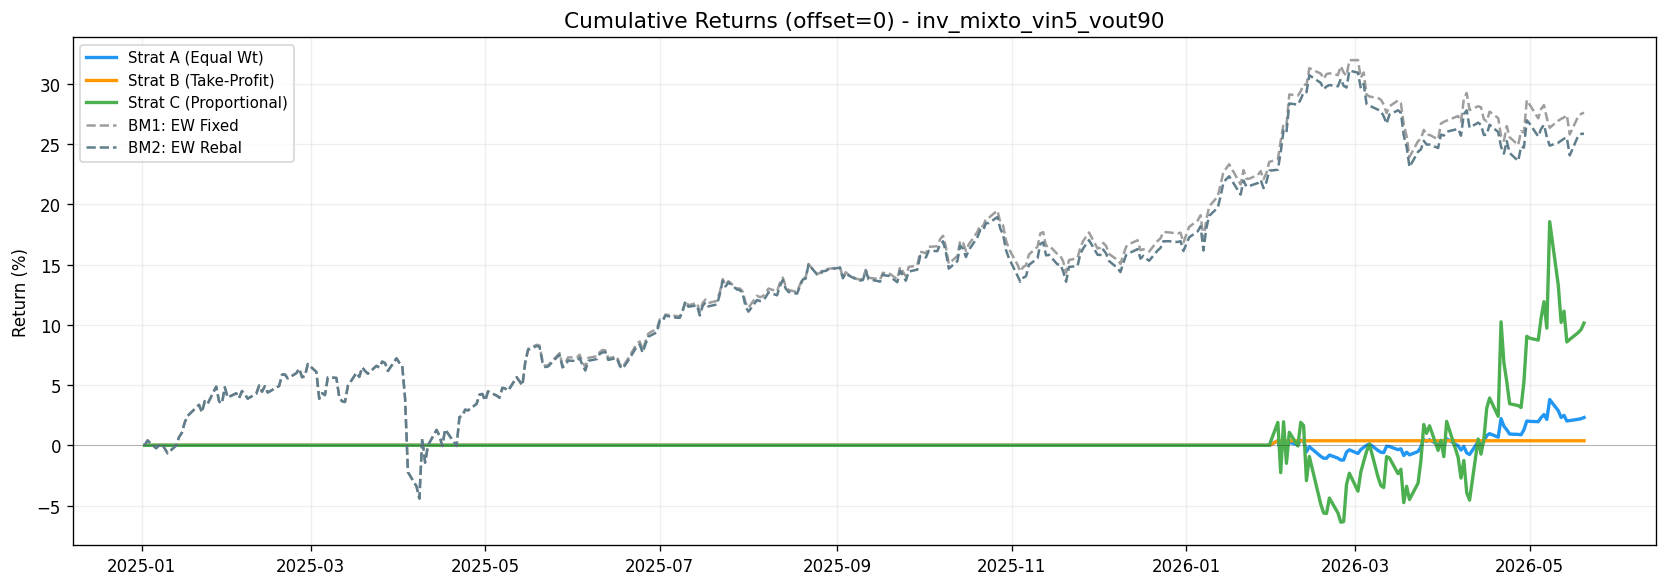

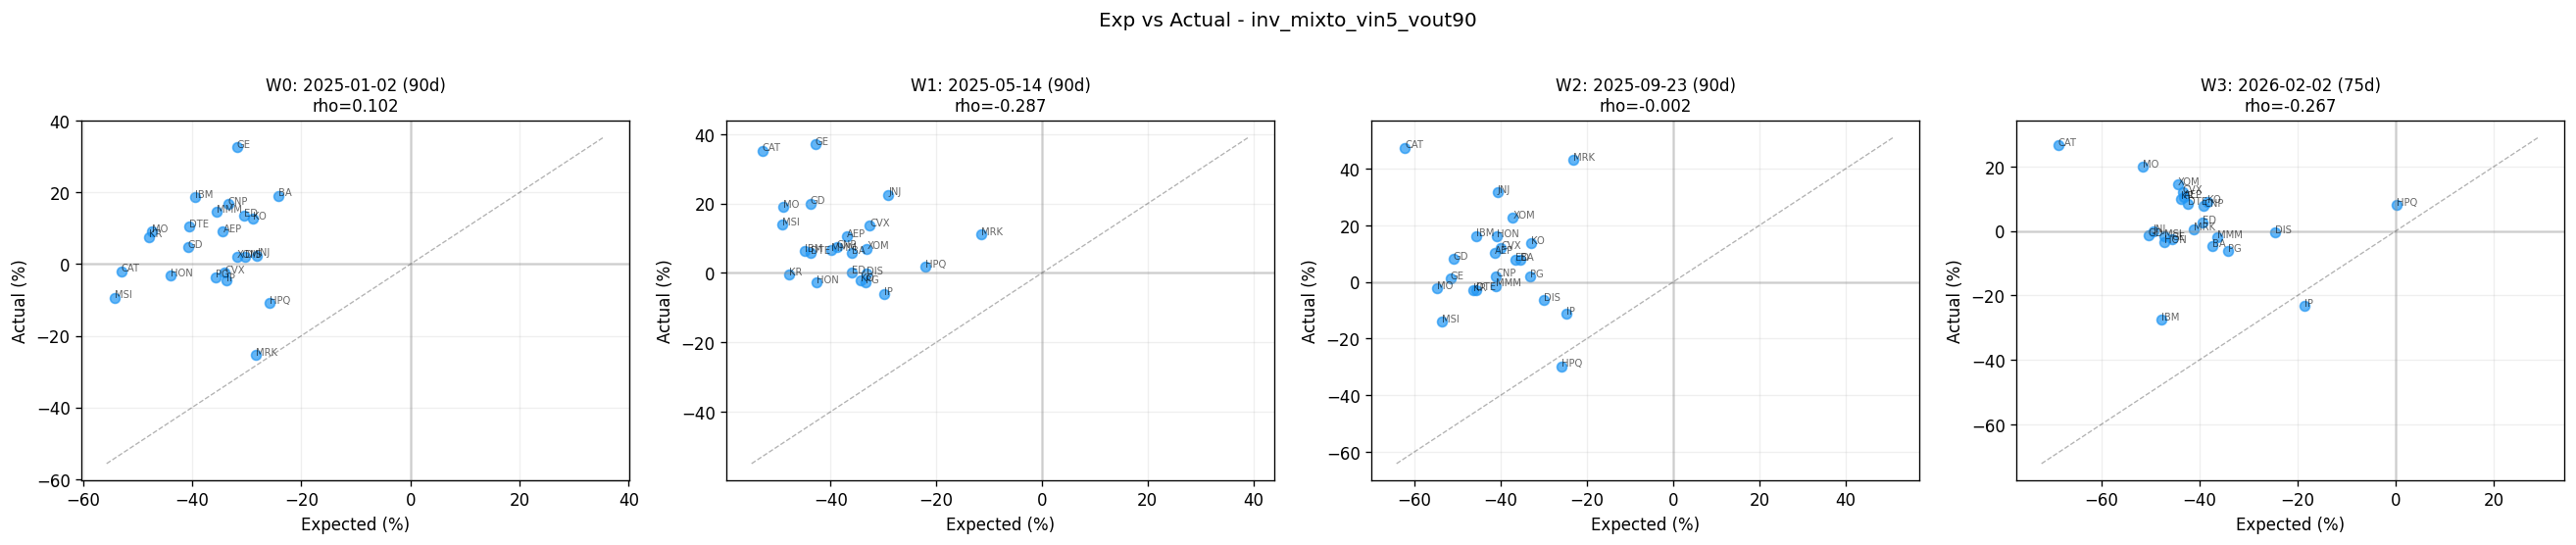

  ✓ Saved to inv_mixto_vin5_vout90/ (23s)

######################################################################
  MODEL [7/12]: inv_mixto_vin90_vout90
  v_in=90  v_out=90  file=inv_mixto_vin90_vout90_best.weights.h5
######################################################################
  Scaler: X_tr (11294, 90, 23)


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 28 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


> Auto-built mixto: 310,295 params from inv_mixto_vin90_vout90_best.weights.h5
  MAE tr=0.05528  val=0.08720  test=0.10479
  ⚠ Offset 0: Last window: 75/90 days (data ends 2026-05-20)
  ⚠ Offset 0: Window 3: 75/90 days
  ⚠ Offset 5: Last window: 70/90 days (data ends 2026-05-20)
  ⚠ Offset 5: Window 3: 70/90 days
  ⚠ Offset 10: Last window: 65/90 days (data ends 2026-05-20)
  ⚠ Offset 10: Window 3: 65/90 days
  ⚠ Offset 15: Last window: 60/90 days (data ends 2026-05-20)
  ⚠ Offset 15: Window 3: 60/90 days
  ⚠ Offset 20: Last window: 55/90 days (data ends 2026-05-20)
  ⚠ Offset 20: Window 3: 55/90 days
  AVG: A=+0.00%  B=+0.00%  C=+0.00%  BM1=+24.84%  BM2=+23.54%


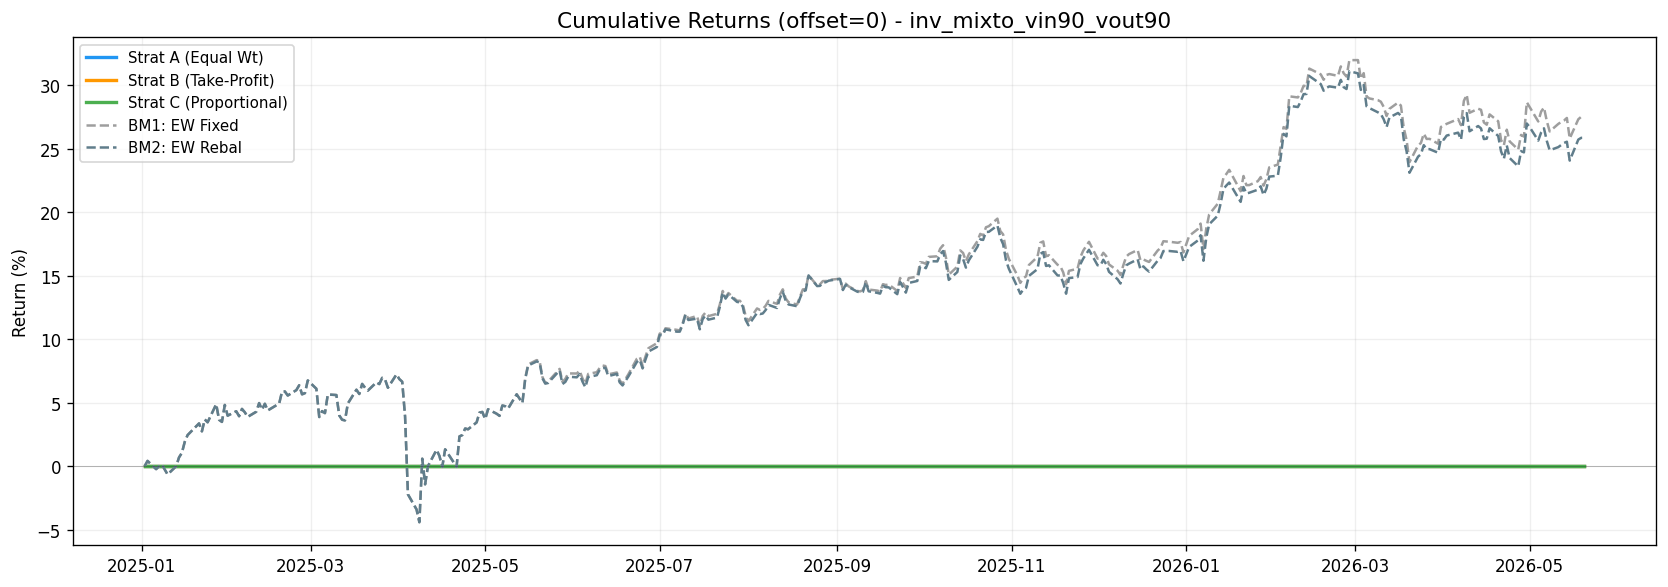

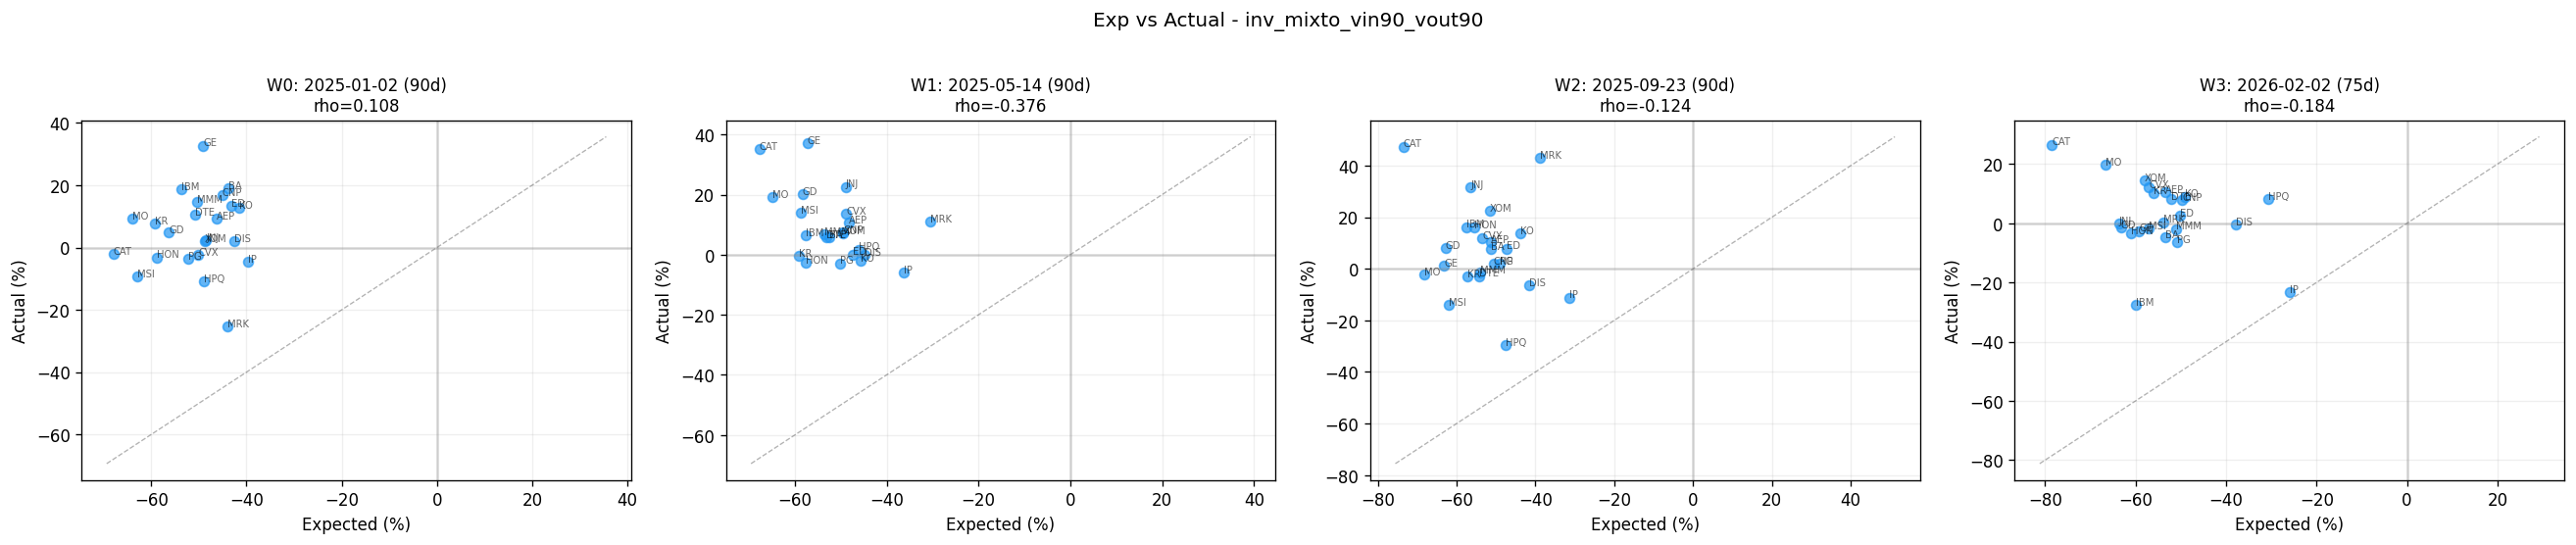

  ✓ Saved to inv_mixto_vin90_vout90/ (60s)

######################################################################
  MODEL [8/12]: inv_mlp_vin10_vout90
  v_in=10  v_out=90  file=inv_mlp_vin10_vout90_best.weights.h5
######################################################################
  Scaler: X_tr (11518, 10, 23)


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


> Auto-built mlp: 5,313 params from inv_mlp_vin10_vout90_best.weights.h5
  MAE tr=0.01543  val=0.01651  test=0.02103
  ⚠ Offset 0: Last window: 75/90 days (data ends 2026-05-20)
  ⚠ Offset 0: Window 3: 75/90 days
  ⚠ Offset 5: Last window: 70/90 days (data ends 2026-05-20)
  ⚠ Offset 5: Window 3: 70/90 days
  ⚠ Offset 10: Last window: 65/90 days (data ends 2026-05-20)
  ⚠ Offset 10: Window 3: 65/90 days
  ⚠ Offset 15: Last window: 60/90 days (data ends 2026-05-20)
  ⚠ Offset 15: Window 3: 60/90 days
  ⚠ Offset 20: Last window: 55/90 days (data ends 2026-05-20)
  ⚠ Offset 20: Window 3: 55/90 days
  AVG: A=+48.95%  B=+41.86%  C=+49.62%  BM1=+24.84%  BM2=+23.54%


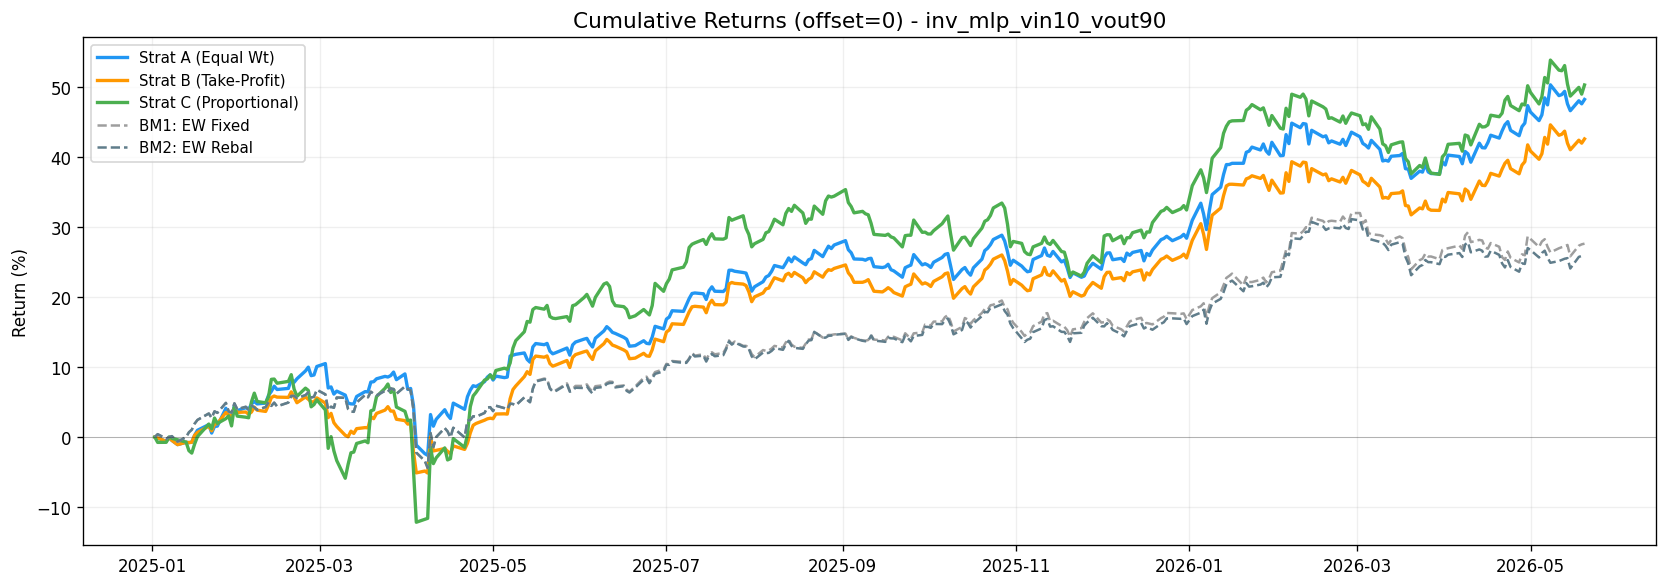

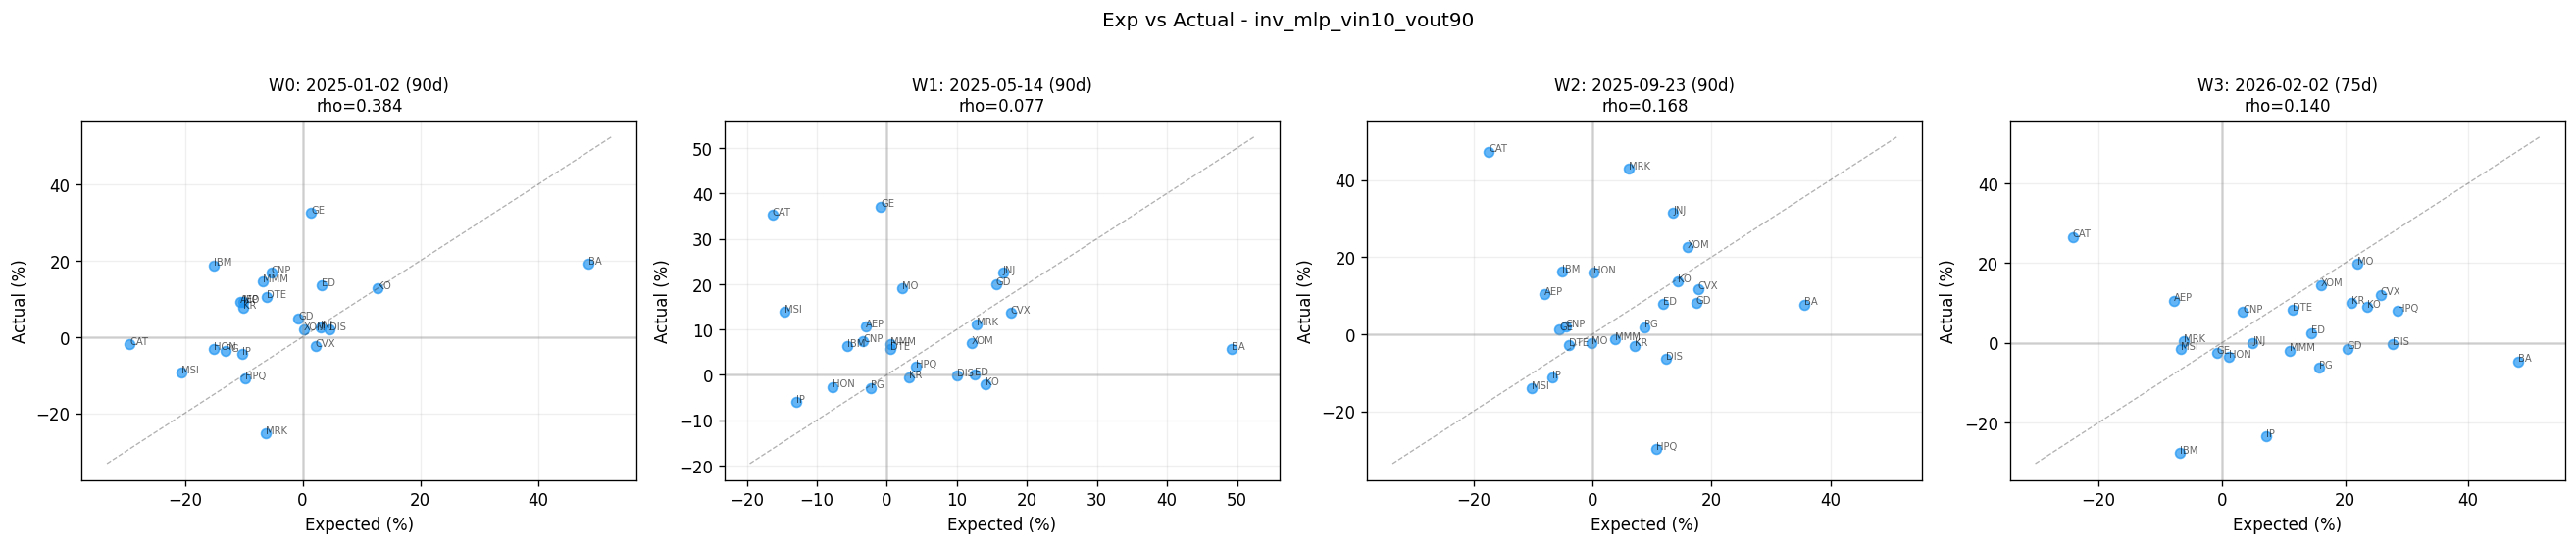

  ✓ Saved to inv_mlp_vin10_vout90/ (20s)

######################################################################
  MODEL [9/12]: inv_mlp_vin5_vout90
  v_in=5  v_out=90  file=inv_mlp_vin5_vout90_best.weights.h5
######################################################################
  Scaler: X_tr (11533, 5, 23)


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


> Auto-built mlp: 65,559 params from inv_mlp_vin5_vout90_best.weights.h5
  MAE tr=0.02204  val=0.02243  test=0.02639
  ⚠ Offset 0: Last window: 75/90 days (data ends 2026-05-20)
  ⚠ Offset 0: Window 3: 75/90 days
  ⚠ Offset 5: Last window: 70/90 days (data ends 2026-05-20)
  ⚠ Offset 5: Window 3: 70/90 days
  ⚠ Offset 10: Last window: 65/90 days (data ends 2026-05-20)
  ⚠ Offset 10: Window 3: 65/90 days
  ⚠ Offset 15: Last window: 60/90 days (data ends 2026-05-20)
  ⚠ Offset 15: Window 3: 60/90 days
  ⚠ Offset 20: Last window: 55/90 days (data ends 2026-05-20)
  ⚠ Offset 20: Window 3: 55/90 days
  AVG: A=+25.37%  B=+11.16%  C=+43.78%  BM1=+24.84%  BM2=+23.54%


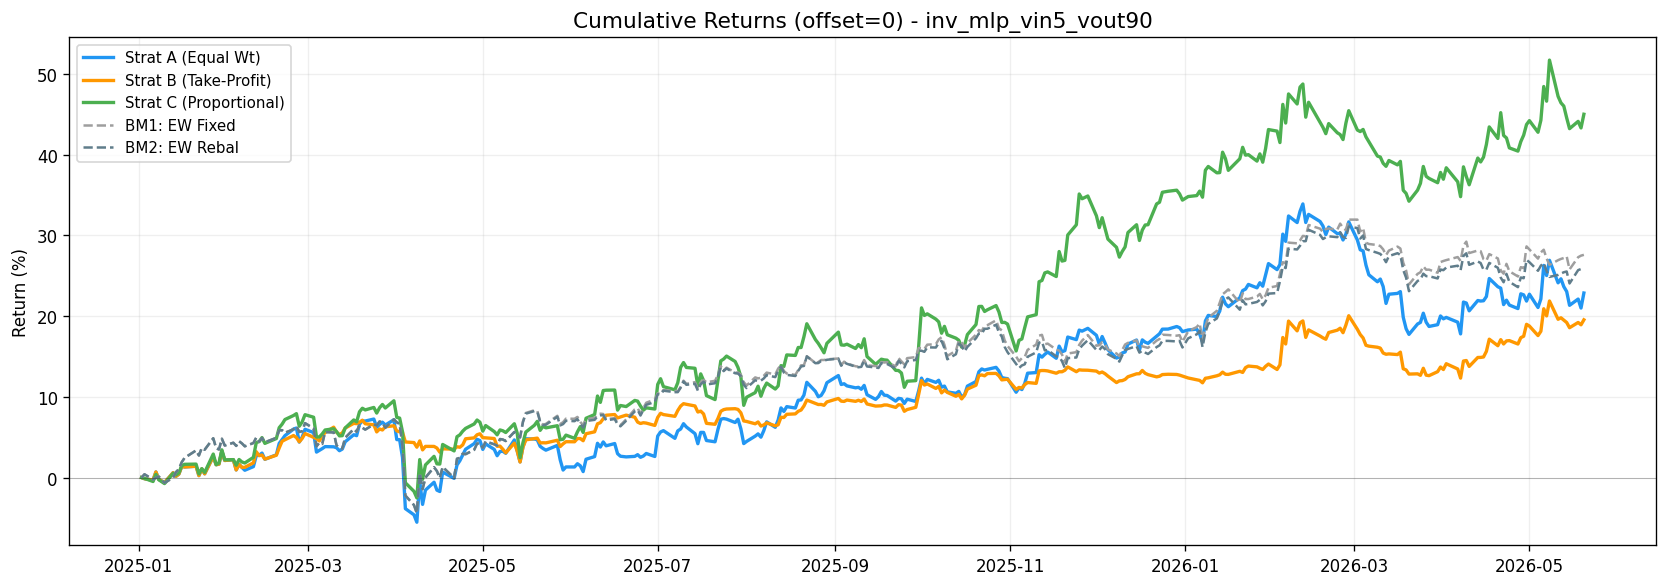

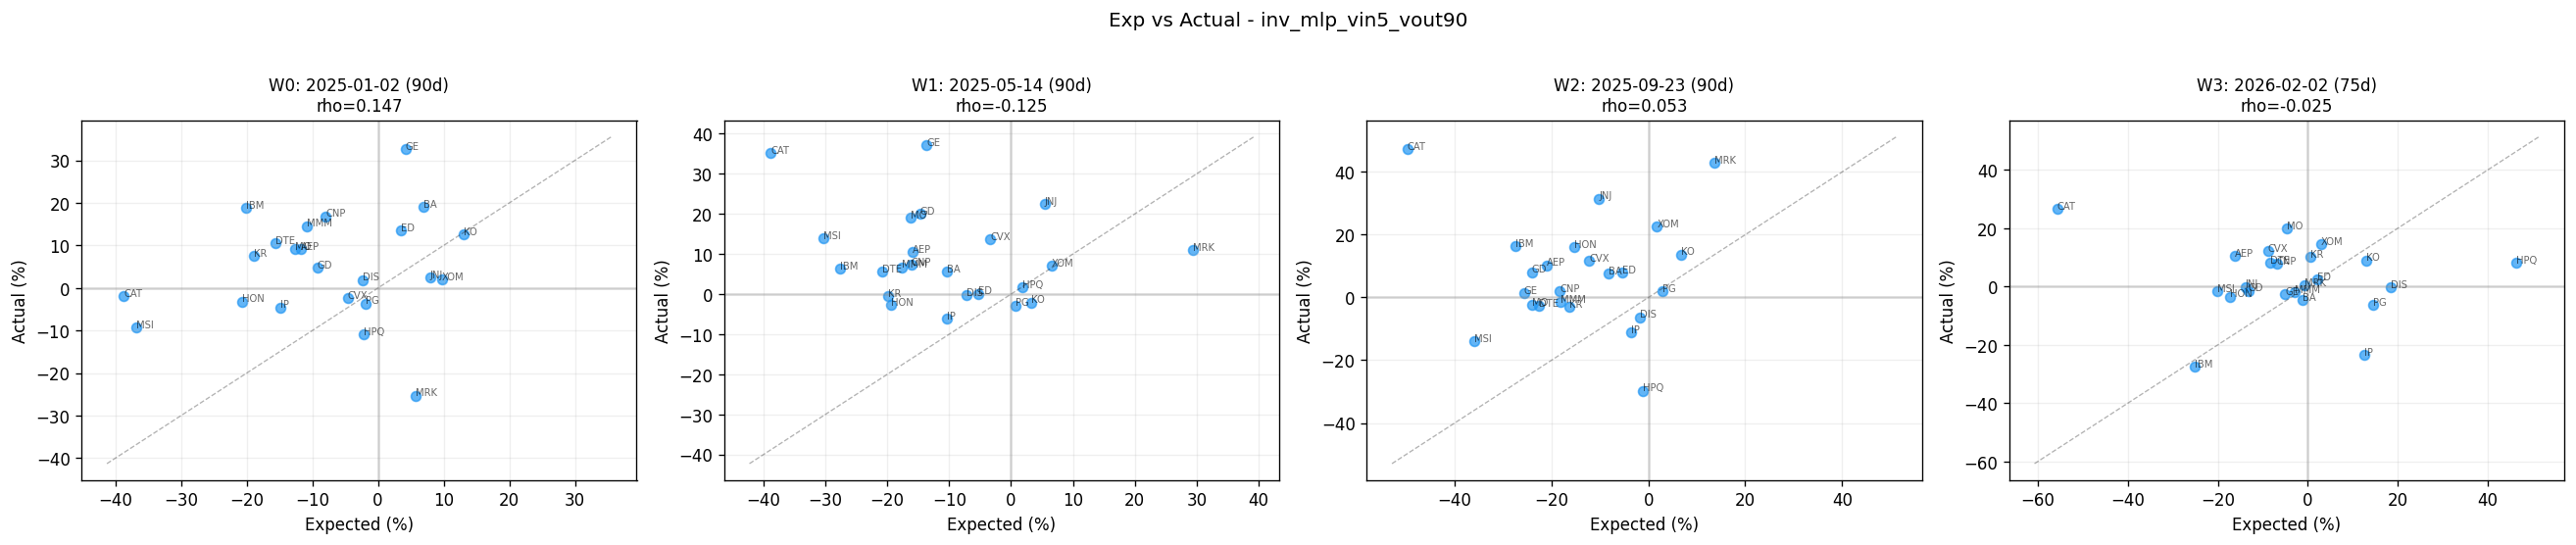

  ✓ Saved to inv_mlp_vin5_vout90/ (22s)

######################################################################
  MODEL [10/12]: inv_mlp_vin90_vout90
  v_in=90  v_out=90  file=inv_mlp_vin90_vout90_best.weights.h5
######################################################################
  Scaler: X_tr (11294, 90, 23)


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


> Auto-built mlp: 615,575 params from inv_mlp_vin90_vout90_best.weights.h5
  MAE tr=0.02115  val=0.04366  test=0.06073
  ⚠ Offset 0: Last window: 75/90 days (data ends 2026-05-20)
  ⚠ Offset 0: Window 3: 75/90 days
  ⚠ Offset 5: Last window: 70/90 days (data ends 2026-05-20)
  ⚠ Offset 5: Window 3: 70/90 days
  ⚠ Offset 10: Last window: 65/90 days (data ends 2026-05-20)
  ⚠ Offset 10: Window 3: 65/90 days
  ⚠ Offset 15: Last window: 60/90 days (data ends 2026-05-20)
  ⚠ Offset 15: Window 3: 60/90 days
  ⚠ Offset 20: Last window: 55/90 days (data ends 2026-05-20)
  ⚠ Offset 20: Window 3: 55/90 days
  AVG: A=+2.18%  B=+0.53%  C=+10.27%  BM1=+24.84%  BM2=+23.54%


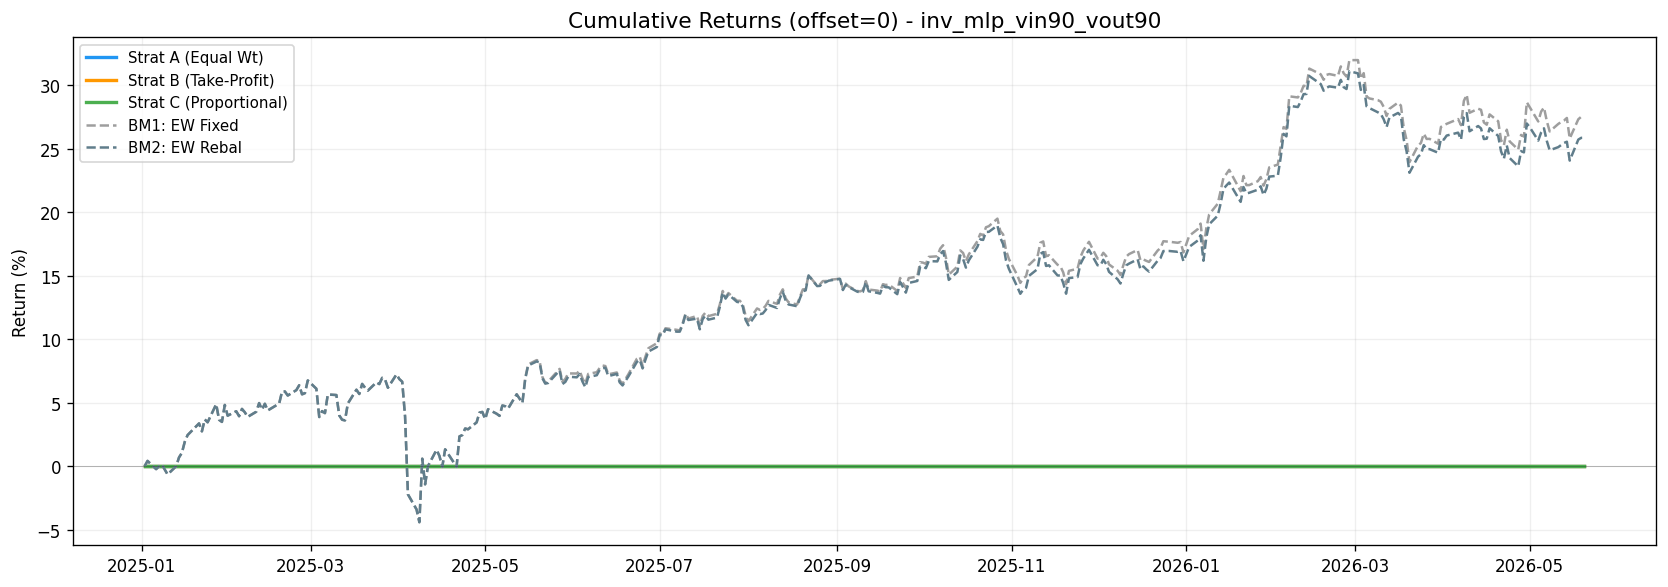

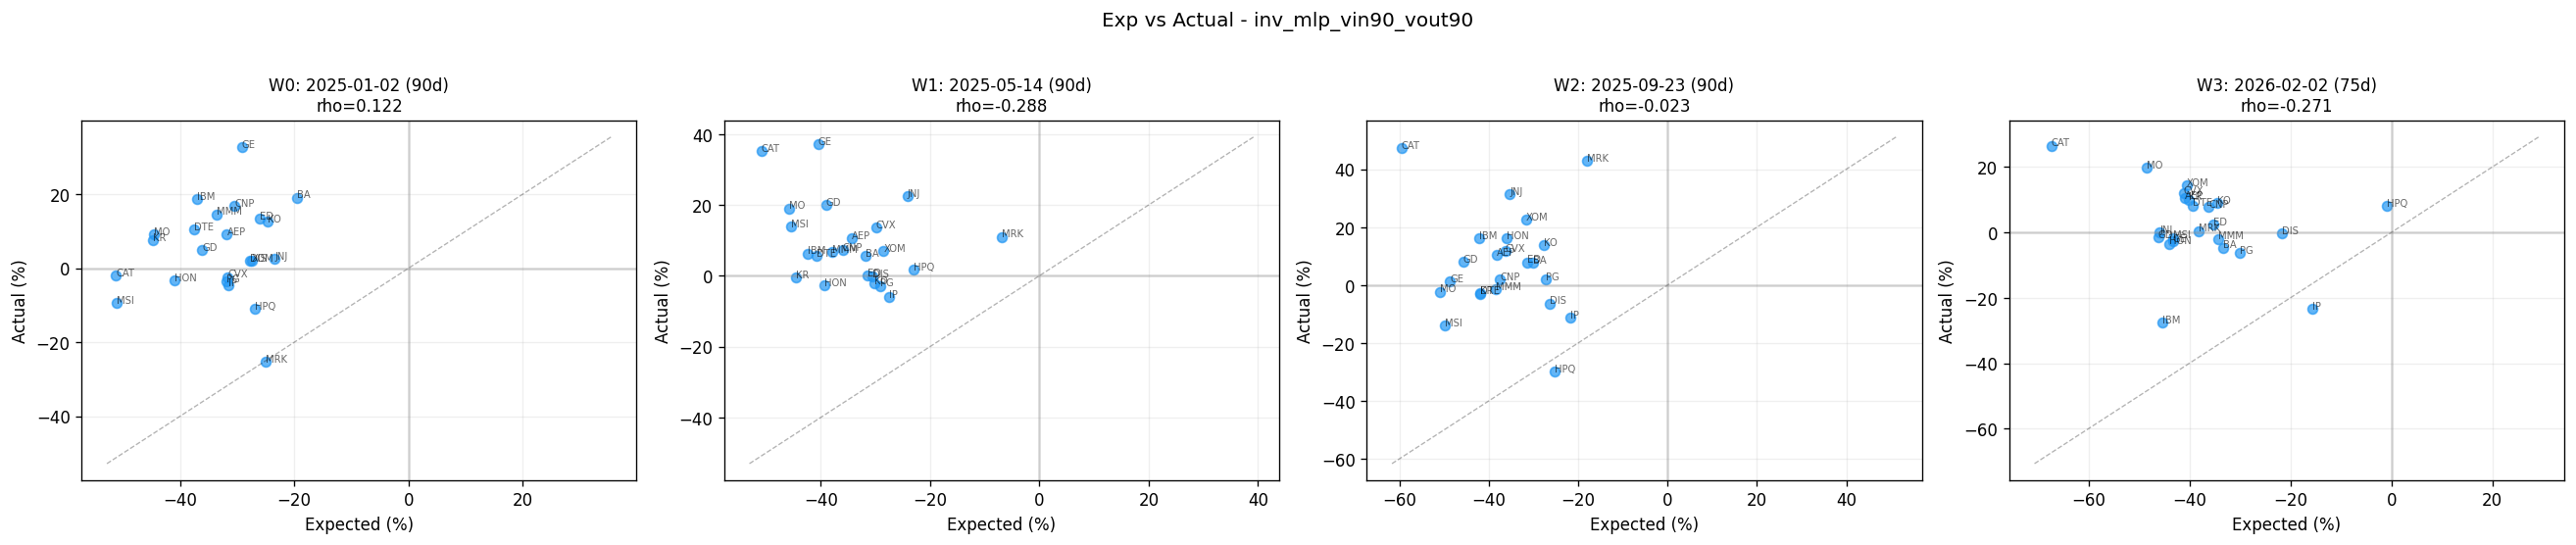

  ✓ Saved to inv_mlp_vin90_vout90/ (21s)

######################################################################
  MODEL [11/12]: inv_rnn_vin30_vout90
  v_in=30  v_out=90  file=inv_rnn_vin30_vout90_best.weights.h5
######################################################################
  Scaler: X_tr (11462, 30, 23)


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 16 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


> Auto-built rnn: 28,183 params from inv_rnn_vin30_vout90_best.weights.h5
  MAE tr=0.01787  val=0.02422  test=0.04037
  ⚠ Offset 0: Last window: 75/90 days (data ends 2026-05-20)
  ⚠ Offset 0: Window 3: 75/90 days
  ⚠ Offset 5: Last window: 70/90 days (data ends 2026-05-20)
  ⚠ Offset 5: Window 3: 70/90 days
  ⚠ Offset 10: Last window: 65/90 days (data ends 2026-05-20)
  ⚠ Offset 10: Window 3: 65/90 days
  ⚠ Offset 15: Last window: 60/90 days (data ends 2026-05-20)
  ⚠ Offset 15: Window 3: 60/90 days
  ⚠ Offset 20: Last window: 55/90 days (data ends 2026-05-20)
  ⚠ Offset 20: Window 3: 55/90 days
  AVG: A=+6.37%  B=+4.22%  C=+36.12%  BM1=+24.84%  BM2=+23.54%


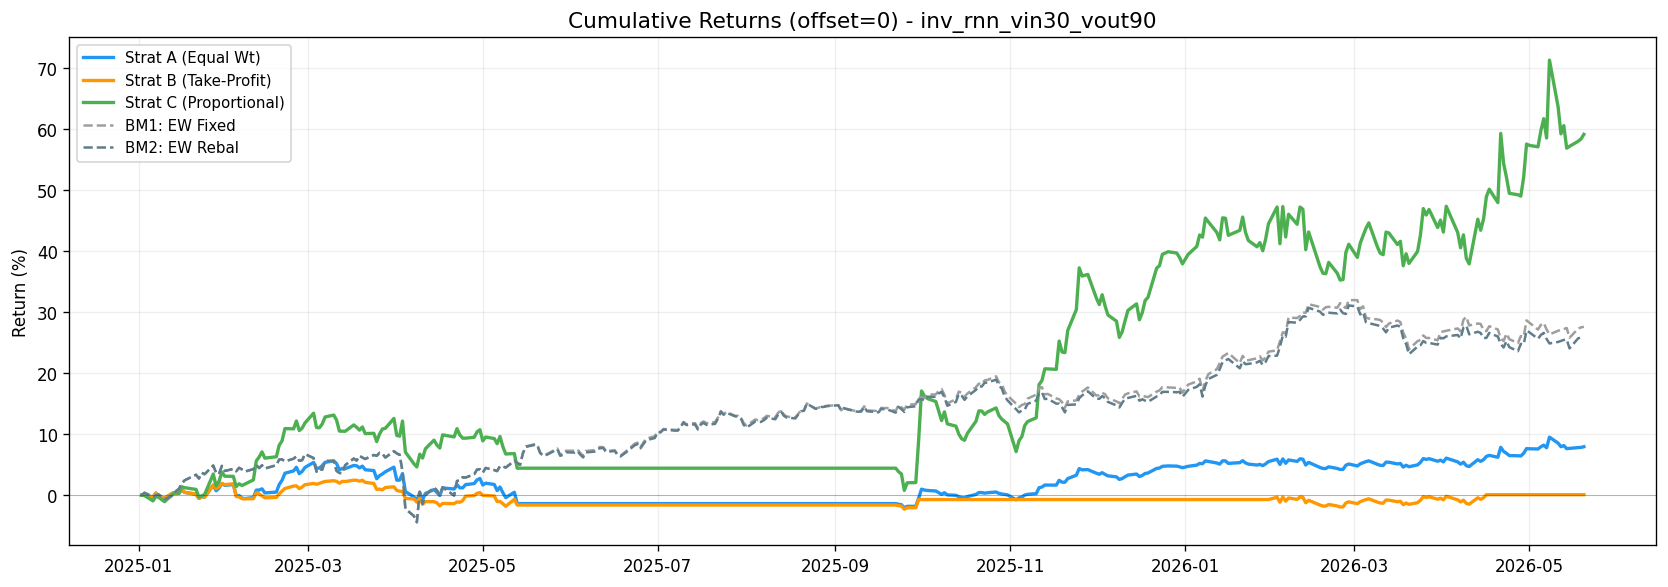

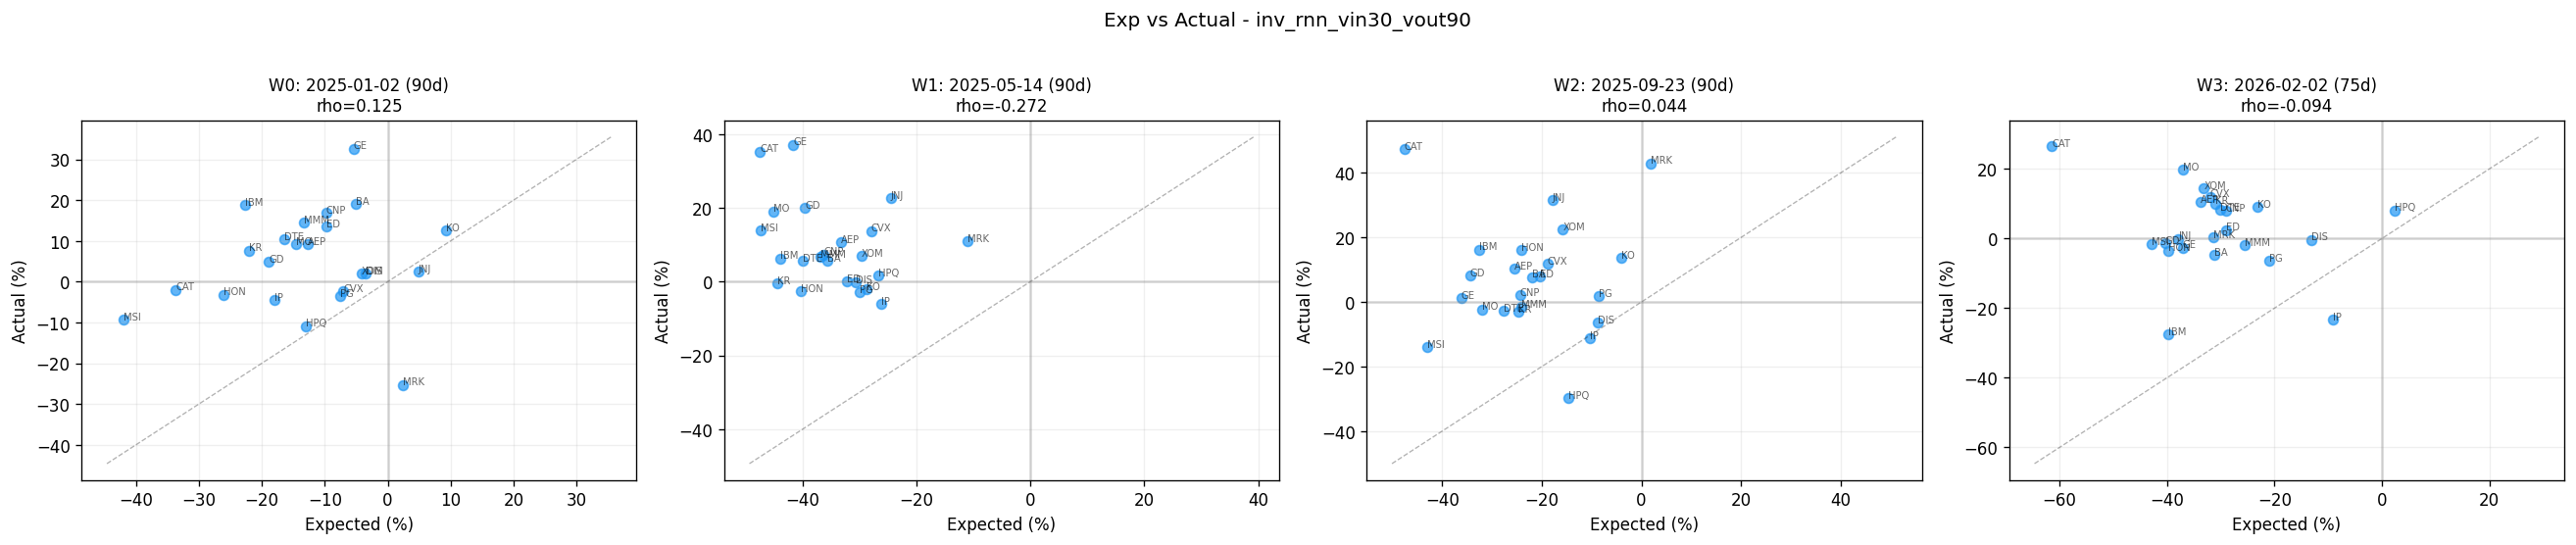

  ✓ Saved to inv_rnn_vin30_vout90/ (22s)

######################################################################
  MODEL [12/12]: inv_rnn_vin5_vout90
  v_in=5  v_out=90  file=inv_rnn_vin5_vout90_best.weights.h5
######################################################################
  Scaler: X_tr (11533, 5, 23)


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 38 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


> Auto-built cnn: 253,463 params from inv_rnn_vin5_vout90_best.weights.h5
  MAE tr=0.01060  val=0.02425  test=0.04062
  ⚠ Offset 0: Last window: 75/90 days (data ends 2026-05-20)
  ⚠ Offset 0: Window 3: 75/90 days
  ⚠ Offset 5: Last window: 70/90 days (data ends 2026-05-20)
  ⚠ Offset 5: Window 3: 70/90 days
  ⚠ Offset 10: Last window: 65/90 days (data ends 2026-05-20)
  ⚠ Offset 10: Window 3: 65/90 days
  ⚠ Offset 15: Last window: 60/90 days (data ends 2026-05-20)
  ⚠ Offset 15: Window 3: 60/90 days
  ⚠ Offset 20: Last window: 55/90 days (data ends 2026-05-20)
  ⚠ Offset 20: Window 3: 55/90 days
  AVG: A=+4.58%  B=+1.59%  C=+23.09%  BM1=+24.84%  BM2=+23.54%


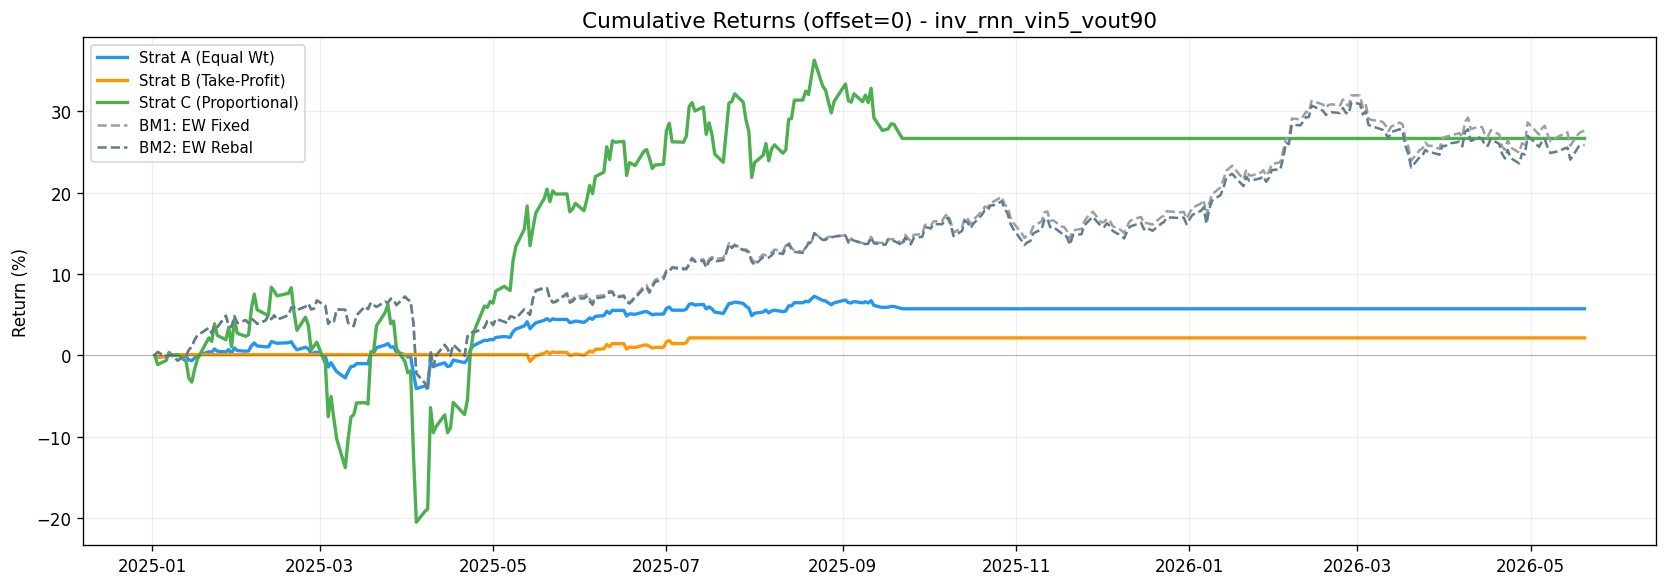

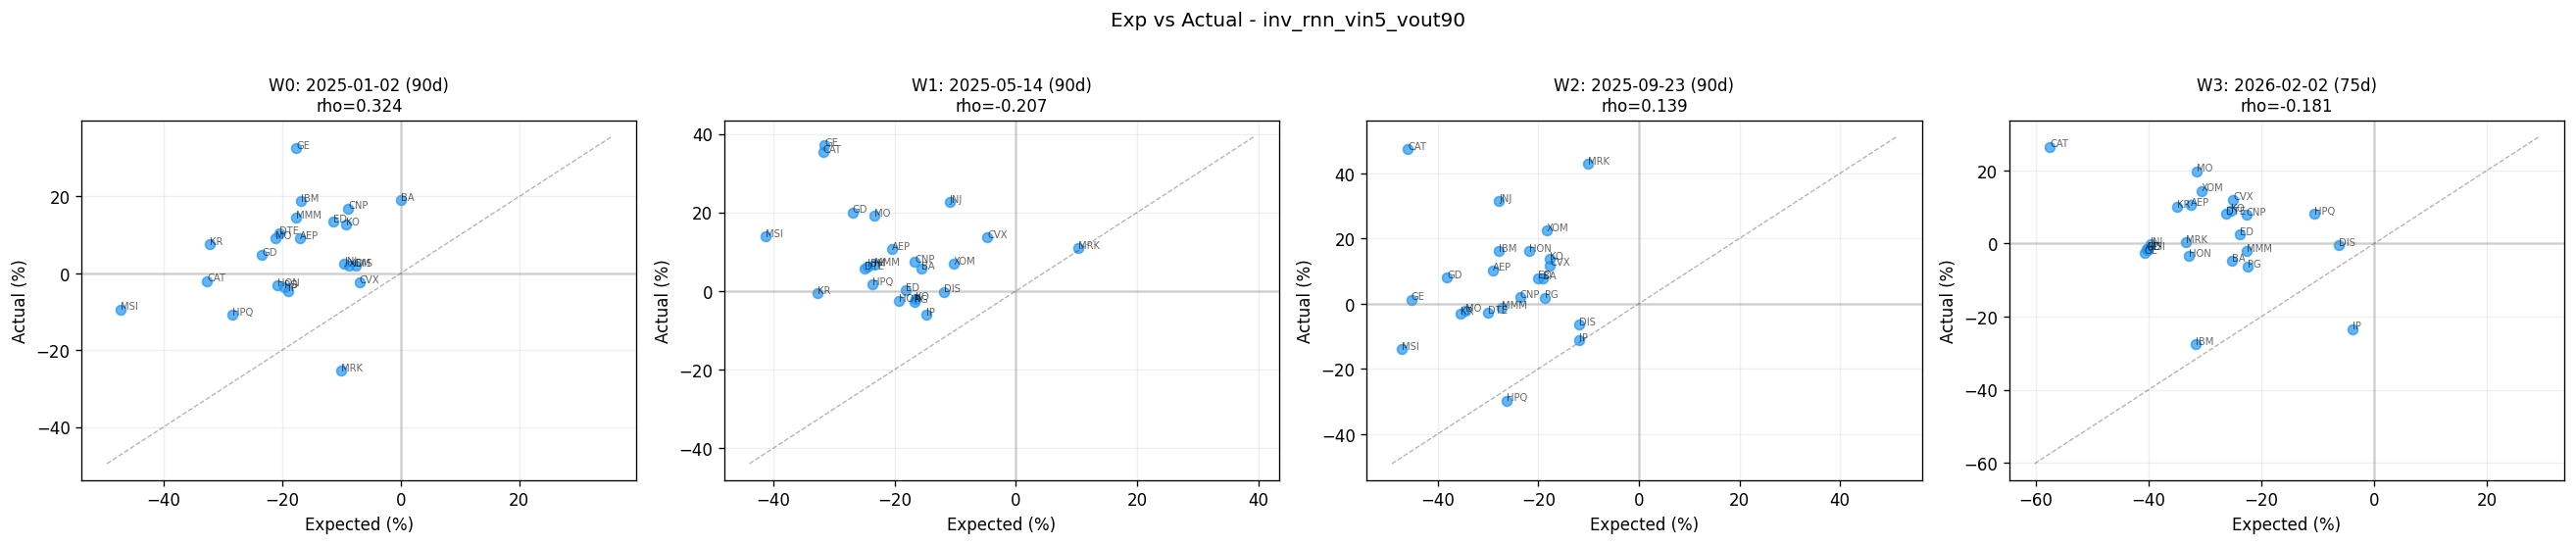

  ✓ Saved to inv_rnn_vin5_vout90/ (26s)

BATCH COMPLETE
  Successful: 11/12
  Failed:     1/12


In [13]:
COLORS = {'A':'#2196F3','B':'#FF9800','C':'#4CAF50','BM1':'#9E9E9E','BM2':'#607D8B'}
LABELS = {'A':'Strat A (Equal Wt)','B':'Strat B (Take-Profit)',
          'C':'Strat C (Proportional)','BM1':'BM1: EW Fixed','BM2':'BM2: EW Rebal'}
LS = {'A':'-','B':'-','C':'-','BM1':'--','BM2':'--'}
LW = {'A':2,'B':2,'C':2,'BM1':1.5,'BM2':1.5}

all_model_results = {}
failed_models = []

for ck_idx, ck in enumerate(checkpoints):
    run_tag = ck['run_tag']
    v_in = ck['v_in']

    print(f'\n{"#"*70}')
    print(f'  MODEL [{ck_idx+1}/{len(checkpoints)}]: {run_tag}')
    print(f'  v_in={v_in}  v_out={V_OUT}  file={ck["filename"]}')
    print(f'{"#"*70}')

    try:
        t0 = time.time()

        # ── Reconstruct scaler ──
        X_all, Y_all = create_dataset(data_fd, v_in, V_OUT, verbose=False)
        X_tr, X_val, X_test, Y_tr, Y_val, Y_test, scaler_obj = get_partitions_temporal(
            X_all, Y_all, v_in=v_in, v_out=V_OUT,
            scaler='standard', return_scaler=True,
            random_state=RANDOM_STATE_VAL, verbose=False,
        )
        print(f'  Scaler: X_tr {X_tr.shape}')

        # ── Auto-detect architecture and load ──
        model_obj, arch_detected = build_and_load_from_h5(ck['path'], v_in, N_ASSETS)

        # ── MAE ──
        maes = calc_mae_all(model_obj, X_tr, Y_tr, X_val, Y_val, X_test, Y_test)
        print(f'  MAE tr={maes["train"]:.5f}  val={maes["val"]:.5f}  test={maes["test"]:.5f}')

        # ── Run offsets ──
        results = []
        for off in OFFSETS:
            r = run_single_backtest(off, model_obj, scaler_obj, v_in)
            results.append(r)
            for a in r['alerts']:
                print(f'  \u26a0 Offset {off}: {a}')

        avg_ret = {k: np.mean([r['final_ret'][k] for r in results]) for k in ['A','B','C','BM1','BM2']}
        print(f'  AVG: A={avg_ret["A"]:+.2%}  B={avg_ret["B"]:+.2%}  '
              f'C={avg_ret["C"]:+.2%}  BM1={avg_ret["BM1"]:+.2%}  BM2={avg_ret["BM2"]:+.2%}')

        # ── Save ──
        out_dir = os.path.join(PORTFOLIO_DIR, run_tag)
        if os.path.isdir(out_dir):
            for f in os.listdir(out_dir):
                fp = os.path.join(out_dir, f)
                if os.path.isfile(fp): os.remove(fp)
        os.makedirs(out_dir, exist_ok=True)

        # Summary CSV
        rows = [{'Offset':r['offset'],'Period':f'{r["start"]} -> {r["end"]}',
                 'Days':r['n_days'], **r['final_ret']} for r in results]
        rows.append({'Offset':'AVG','Period':'','Days':'',**avg_ret})
        rows.append({'Offset':'STD','Period':'','Days':'',
                     **{k:np.std([r['final_ret'][k] for r in results]) for k in avg_ret}})
        pd.DataFrame(rows).to_csv(os.path.join(out_dir,'summary_returns.csv'), index=False)

        # NAV (offset=0)
        pd.DataFrame(results[0]['nav']).to_csv(os.path.join(out_dir,'nav_series_offset0.csv'))

        # Window detail (offset=0)
        det=[]
        for wl in results[0]['window_log']:
            for t,er in zip(wl['selected'],wl['exp_returns']):
                ar=wl['actual_returns'][t]; wc=wl['weights_c'][t]
                det.append({'window':wl['window'],'rebal_date':wl['rebal_date'],
                    'end_date':wl['end_date'],'days':wl['actual_days'],'ticker':t,
                    'weight_eq':1./TOP_K,'weight_prop':wc,
                    'exp_return':er,'actual_return':ar,
                    'direction_correct':int(np.sign(er)==np.sign(ar))})
        pd.DataFrame(det).to_csv(os.path.join(out_dir,'window_detail.csv'), index=False)

        # Chart: cumulative returns (offset=0)
        fig, ax = plt.subplots(figsize=(14, 5))
        for k, nav in results[0]['nav'].items():
            ax.plot(nav.index,(nav-1)*100,label=LABELS[k],color=COLORS[k],lw=LW[k],ls=LS[k])
        ax.axhline(0,color='black',lw=0.5,alpha=0.3)
        ax.set_title(f'Cumulative Returns (offset=0) - {run_tag}',fontsize=13)
        ax.set_ylabel('Return (%)'); ax.legend(loc='best',fontsize=9); ax.grid(True,alpha=0.2)
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir,'cumulative_returns.png'),dpi=150,bbox_inches='tight')
        plt.show()

        # Chart: scatter (offset=0)
        wlogs = results[0]['window_log']
        nw = len(wlogs)
        fig, axes = plt.subplots(1, nw, figsize=(5.5*nw, 4.5))
        if nw == 1: axes = [axes]
        for i, wl in enumerate(wlogs):
            rd=pd.Timestamp(wl['rebal_date']); ed=pd.Timestamp(wl['end_date'])
            _,ef=run_inference_at_date(rd, model_obj, scaler_obj, v_in)
            af=np.array([(prices_df.loc[ed,t]/prices_df.loc[rd,t])-1 for t in TICKERS])
            ax=axes[i]
            ax.scatter(ef*100,af*100,alpha=0.7,s=35,color='#2196F3')
            for j,t in enumerate(TICKERS):
                ax.annotate(t,(ef[j]*100,af[j]*100),fontsize=6,alpha=0.6)
            lm=[min(ax.get_xlim()[0],ax.get_ylim()[0]),max(ax.get_xlim()[1],ax.get_ylim()[1])]
            ax.plot(lm,lm,'k--',alpha=0.3,lw=0.8)
            ax.axhline(0,color='gray',alpha=0.3); ax.axvline(0,color='gray',alpha=0.3)
            rho=wl.get('spearman_rho',0) or 0
            ax.set_title(f'W{i}: {rd.date()} ({wl["actual_days"]}d)\nrho={rho:.3f}',fontsize=10)
            ax.set_xlabel('Expected (%)'); ax.set_ylabel('Actual (%)'); ax.grid(True,alpha=0.2)
        plt.suptitle(f'Exp vs Actual - {run_tag}',fontsize=12,y=1.02)
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir,'scatter_exp_vs_actual.png'),dpi=150,bbox_inches='tight')
        plt.show()

        # Model metadata
        meta = {
            'run_tag':run_tag,'arch':arch_detected,'v_in':v_in,'v_out':V_OUT,
            'd_frac':D_FRAC_INV,'top_k':TOP_K,'cash_rate':CASH_RATE,
            'n_assets':N_ASSETS,'tickers':TICKERS,'offsets':OFFSETS,
            'mae_train':maes['train'],'mae_val':maes['val'],'mae_test':maes['test'],
            'avg_returns':avg_ret,
            'per_offset':[{'offset':r['offset'],'start':r['start'],'end':r['end'],
                           'returns':r['final_ret'],'alerts':r['alerts']} for r in results],
        }
        with open(os.path.join(out_dir,'model_meta.json'),'w') as f:
            json.dump(meta,f,indent=2,default=str)

        all_model_results[run_tag] = {'results':results,'avg_ret':avg_ret,'maes':maes,
                                      'arch':arch_detected,'ck':ck}

        elapsed = time.time() - t0
        print(f'  \u2713 Saved to {run_tag}/ ({elapsed:.0f}s)')

    except Exception as e:
        error_msg = f'{type(e).__name__}: {str(e)[:200]}'
        failed_models.append({'run_tag': run_tag, 'error': error_msg})
        print(f'  \u2717 FAILED: {error_msg}')
        print(f'  Skipping to next model...\n')
        continue

print(f'\n{"="*70}')
print(f'BATCH COMPLETE')
print(f'  Successful: {len(all_model_results)}/{len(checkpoints)}')
print(f'  Failed:     {len(failed_models)}/{len(checkpoints)}')
print(f'{"="*70}')

---
## <font color=#0099CC>**6. BATCH SUMMARY**</font>

In [6]:
# ── Successful models ──
if all_model_results:
    print(f'\n{"Model":35s}  {"Arch":>6s}  {"MAE":>8s}  {"A":>8s}  {"B":>8s}  {"C":>8s}  {"BM1":>8s}  {"BM2":>8s}')
    print('-' * 100)
    for tag, data in sorted(all_model_results.items()):
        ar = data['avg_ret']
        mae = data['maes']['test']
        arch = data['arch']
        print(f'{tag:35s}  {arch:>6s}  {mae:>8.5f}  {ar["A"]:>+8.2%}  {ar["B"]:>+8.2%}  '
              f'{ar["C"]:>+8.2%}  {ar["BM1"]:>+8.2%}  {ar["BM2"]:>+8.2%}')
    print(f'\n(Avg total returns across {len(OFFSETS)} offsets)')

# ── Failed models ──
if failed_models:
    print(f'\n-- FAILED MODELS --')
    for fm in failed_models:
        print(f'  \u2717 {fm["run_tag"]}')
        print(f'    {fm["error"]}')
    print(f'\n  These models likely have an architecture that could not be auto-detected.')
    print(f'  To fix: inspect the .h5 file and add support in model_builder.py.')
else:
    print(f'\nAll models ran successfully.')


Model                                  Arch       MAE         A         B         C       BM1       BM2
----------------------------------------------------------------------------------------------------
inv_cnn_vin10_vout90                    cnn   0.02600   +16.40%   +13.03%   +35.01%   +24.84%   +23.54%
inv_mixto_vin5_vout90                 mixto   0.06884    +2.64%    +1.54%   +12.29%   +24.84%   +23.54%
inv_mixto_vin90_vout90                mixto   0.10479    +0.00%    +0.00%    +0.00%   +24.84%   +23.54%
inv_mlp_vin10_vout90                    mlp   0.02103   +48.95%   +41.86%   +49.62%   +24.84%   +23.54%
inv_mlp_vin5_vout90                     mlp   0.02639   +25.37%   +11.16%   +43.78%   +24.84%   +23.54%
inv_mlp_vin90_vout90                    mlp   0.06073    +2.18%    +0.53%   +10.27%   +24.84%   +23.54%
inv_rnn_vin30_vout90                    rnn   0.04037    +6.37%    +4.22%   +36.12%   +24.84%   +23.54%

(Avg total returns across 5 offsets)

All models ran successfully